# 07 — Final Results and Replication Comparison

## Deep Learning in Asset Pricing — Chen, Pelger, and Zhu

### Purpose of this notebook

This notebook consolidates the outputs from the preceding replication notebooks and performs the final evaluation of the replicated asset-pricing models.

**No core model is re-estimated in Code 07.**  
Instead, the notebook loads the saved outputs from the LS, Elastic Net, FFN, LSTM/GAN preparation, and GAN stages and uses them to evaluate model performance, risk, factor behavior, and interpretability.

The main goal is to assess how closely the replication reproduces the empirical findings of Chen, Pelger, and Zhu, with particular attention to:

- relative model performance across training, validation, and test samples,
- out-of-sample performance,
- comparison with Fama–French benchmarks,
- risk characteristics of the replicated SDF factors,
- similarity between the replicated and official GAN SDFs,
- and the economic interpretation of the variables used by the nonlinear models.

Exact numerical equality with the paper is not required. The emphasis is on whether the replication preserves the main empirical and economic conclusions.

---

### Main objectives

1. Compare the replicated **LS, Elastic Net, FFN, and GAN** SDF factor Sharpe ratios with the values reported in the paper.
2. Reconstruct the **Fama–French 3-factor and 5-factor tangency-portfolio benchmarks** using Kenneth French monthly factor data.
3. Compare the ranking of the replicated models with the ranking reported in the paper.
4. Examine the time-series behavior and correlations of the replicated SDF factors.
5. Compare the replicated factors with the market factor, following the paper's factor-correlation analysis.
6. Reproduce paper-style **risk measures**, including:
   - monthly Sharpe ratio,
   - maximum one-month loss measured in volatility units,
   - maximum consecutive losing months.
7. Validate the replicated GAN ensemble against the supplied official GAN SDF time series.
8. Estimate **GAN firm-characteristic importance** using average absolute input gradients on the test sample.
9. Compare characteristic-importance rankings across **LS, Elastic Net, FFN, and GAN**.
10. Optionally evaluate **GAN LSTM input sensitivity** using a contemporaneous local-gradient diagnostic.
11. Save the final comparison tables, factor-return series, risk diagnostics, importance results, and figures.
12. Perform a final integrity check to verify that the required models, observations, sample splits, and output files are complete and internally consistent.

---

### Notebook structure

The analysis proceeds in the following sequence:

**1. Load and standardize saved model outputs**  
Import the performance tables and monthly SDF factor returns generated by the preceding notebooks and place them in a common format.

**2. Core model comparison**  
Compare LS, Elastic Net, FFN, and GAN Sharpe ratios across the training, validation, and test samples.

**3. Paper benchmark comparison and model ranking**  
Measure the differences between the replicated Sharpe ratios and the published values and compare the relative ranking of the models.

**4. Fama–French benchmark construction**  
Construct FF-3 and FF-5 tangency portfolios and evaluate them using the same performance metrics and sample periods.

**5. Expanded performance analysis**  
Combine the Fama–French portfolios with LS, EN, FFN, and GAN for a unified comparison.

**6. Factor-return and correlation analysis**  
Examine correlations among replicated SDF factors and their relationship with the market factor.

**7. Risk analysis**  
Evaluate downside risk and losing-streak behavior and compare the replicated measures with the values reported in the paper.

**8. GAN validation and interpretability**  
Compare the replicated GAN with the official SDF and study firm-characteristic importance and LSTM input sensitivity.

**9. Final output and validation**  
Save all final tables and factor series and run integrity checks to confirm that the replication results are complete.

---

### Sample split

| Sample | Period | Months |
|---|---|---:|
| Training | 1967–1986 | 240 |
| Validation | 1987–1991 | 60 |
| Test | 1992–2016 | 300 |

The full sample therefore contains **600 monthly observations** for each replicated core model.

---

### Paper monthly Sharpe benchmarks

| Model | Train | Validation | Test |
|---|---:|---:|---:|
| FF-3 | 0.27 | -0.09 | 0.19 |
| FF-5 | 0.48 | 0.40 | 0.22 |
| LS | 1.80 | 0.58 | 0.42 |
| EN | 1.37 | 1.15 | 0.50 |
| FFN | 0.45 | 0.42 | 0.44 |
| GAN | 2.68 | 1.43 | 0.75 |

These values provide the reference benchmarks used throughout the notebook to evaluate the quality of the replication.

---

### Evaluation philosophy

The purpose of the replication is not to tune the models until every number exactly matches the published results. Differences may arise from implementation details, numerical optimization, preprocessing, software versions, or other reproducibility factors.

The key questions are whether the replication preserves the paper's main findings, whether the models show similar relative behavior across samples, and whether the nonlinear approaches—especially the GAN—continue to demonstrate strong out-of-sample performance.

The notebook is intentionally organized **part by part** so that each intermediate result can be inspected and validated before proceeding to the next stage.

## Part 1 — Imports and Project Paths

Load the libraries used for final analysis, locate the repository root, and define the results folders.

In [2]:
from pathlib import Path
from io import BytesIO
import re
import urllib.request
import zipfile
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gc
import numpy as np
import torch
import torch.nn as nn

from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def find_repo_root(start=None):
    p = (Path(start) if start is not None else Path.cwd()).resolve()

    for candidate in [p, *p.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root. "
        "Open Jupyter from inside the cloned replication repository."
    )


ROOT = find_repo_root()

RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FACTORS_DIR = RESULTS_DIR / "factors"
MODELS_DIR = RESULTS_DIR / "models"
FIGURES_DIR = RESULTS_DIR / "figures"
EXTERNAL_DIR = ROOT / "data" / "external"

for directory in [
    TABLES_DIR,
    FACTORS_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    EXTERNAL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root :", ROOT)
print("Tables directory:", TABLES_DIR)
print("Factors directory:", FACTORS_DIR)
print("Models directory :", MODELS_DIR)
print("Figures directory:", FIGURES_DIR)

Repository root : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
Tables directory: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables
Factors directory: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/factors
Models directory : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/models
Figures directory: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/figures


## Part 2 — Verify Required Outputs from Previous Notebooks

Code 07 depends on previously saved results rather than re-estimating the models.

In [3]:
FILES = {
    "linear_performance":
        TABLES_DIR / "linear_baseline_performance.csv",

    "linear_factors":
        FACTORS_DIR / "linear_sdf_factor_returns.csv",

    "linear_importance":
        TABLES_DIR / "linear_characteristic_importance.csv",

    "ffn_performance":
        TABLES_DIR / "ffn_performance.csv",

    "ffn_factors":
        FACTORS_DIR / "ffn_sdf_factor_returns.csv",

    "ffn_importance":
        TABLES_DIR / "ffn_characteristic_importance.csv",

    "gan_performance":
        TABLES_DIR / "gan_ensemble_performance.csv",

    "gan_factors":
        FACTORS_DIR / "gan_ensemble_sdf.csv",

    "gan_official":
        TABLES_DIR / "gan_official_sdf_comparison.csv",

    "gan_members":
        TABLES_DIR / "gan_member_summary.csv",

    "macro_input":
        RESULTS_DIR / "macro" / "macro_lstm_input.parquet",
}

file_check = pd.DataFrame(
    [
        {
            "name": name,
            "file": str(path.relative_to(ROOT)),
            "exists": path.exists(),
        }
        for name, path in FILES.items()
    ]
)

display(file_check)

CORE_KEYS = [
    "linear_performance",
    "linear_factors",
    "ffn_performance",
    "ffn_factors",
    "gan_performance",
    "gan_factors",
    "gan_official",
    "gan_members",
]

missing_core = [
    str(FILES[k])
    for k in CORE_KEYS
    if not FILES[k].exists()
]

assert not missing_core, (
    "Missing required output files:\n"
    + "\n".join(missing_core)
)

print("✓ All required core outputs are available.")

,name,file,exists
0,linear_performance,results/tables/linear_baseline_performance.csv,True
1,linear_factors,results/factors/linear_sdf_factor_returns.csv,True
2,linear_importance,results/tables/linear_characteristic_importanc...,True
3,ffn_performance,results/tables/ffn_performance.csv,True
4,ffn_factors,results/factors/ffn_sdf_factor_returns.csv,True
5,ffn_importance,results/tables/ffn_characteristic_importance.csv,True
6,gan_performance,results/tables/gan_ensemble_performance.csv,True
7,gan_factors,results/factors/gan_ensemble_sdf.csv,True
8,gan_official,results/tables/gan_official_sdf_comparison.csv,True
9,gan_members,results/tables/gan_member_summary.csv,True


✓ All required core outputs are available.


## Part 3 — Load Saved Model-Performance Results

Load the final performance tables for the linear models, FFN, and GAN.

In [4]:
linear_performance = pd.read_csv(
    FILES["linear_performance"]
)

ffn_performance = pd.read_csv(
    FILES["ffn_performance"]
)

gan_performance = pd.read_csv(
    FILES["gan_performance"]
)

print("Linear performance:")
display(linear_performance)

print("\nFFN performance:")
display(ffn_performance)

print("\nGAN performance:")
display(gan_performance)

Linear performance:


,model,sample,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,Training,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,LS,Validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
2,LS,Test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
3,EN,Training,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
4,EN,Validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
5,EN,Test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667



FFN performance:


,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,train,240,0.022500,0.034176,0.658348,2.280585,-0.088644,0.314544,0.875000
1,validation,60,0.016209,0.019187,0.844820,2.926543,-0.054613,0.082489,0.883333
2,test,300,0.015039,0.026451,0.568571,1.969586,-0.075809,0.270822,0.800000



GAN performance:


,split,months,mean_monthly,volatility,monthly_sharpe,annualized_sharpe,minimum,maximum,positive_fraction
0,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667
1,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000
2,test,300,0.006997,0.011454,0.610867,2.116105,-0.051845,0.067200,0.823333


In [5]:
# ============================================================
# Diagnostic — Inspect saved linear performance table
# ============================================================

print("Linear performance file:")
print(FILES["linear_performance"])

print("\nColumns:")
print(linear_performance.columns.tolist())

print("\nShape:")
print(linear_performance.shape)

print("\nFull table:")
display(linear_performance)

Linear performance file:
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables/linear_baseline_performance.csv

Columns:
['model', 'sample', 'months', 'mean_monthly', 'volatility_monthly', 'monthly_sharpe', 'annualized_sharpe', 'minimum_month', 'maximum_month', 'positive_month_fraction']

Shape:
(6, 10)

Full table:


,model,sample,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,Training,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,LS,Validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
2,LS,Test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
3,EN,Training,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
4,EN,Validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
5,EN,Test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667


In [6]:
print(
    pd.read_csv(
        FILES["linear_performance"]
    ).head(10).to_string()
)

  model      sample  months  mean_monthly  volatility_monthly  monthly_sharpe  annualized_sharpe  minimum_month  maximum_month  positive_month_fraction
0    LS    Training     240      0.006487            0.003204        2.024811           7.014150      -0.001740       0.014011                 0.975000
1    LS  Validation      60      0.003853            0.005049        0.763148           2.643623      -0.012093       0.012707                 0.816667
2    LS        Test     300      0.003470            0.008554        0.405714           1.405435      -0.053354       0.039867                 0.733333
3    EN    Training     240      0.011631            0.010356        1.123050           3.890359      -0.024542       0.054091                 0.895833
4    EN  Validation      60      0.009537            0.009267        1.029153           3.565092      -0.008959       0.038789                 0.866667
5    EN        Test     300      0.006001            0.014607        0.410822           

## Part 4 — Standardize the Performance Tables

Earlier notebooks used slightly different column names. This section converts all models to a common format and recovers monthly Sharpe from annualized Sharpe when necessary.

In [8]:
# ============================================================
# Part 4 — Standardize the Performance Tables
# ============================================================

def normalize_split_names(series):
    """
    Convert possible split labels to the common convention:
    train / validation / test
    """
    mapping = {
        "train": "train",
        "training": "train",
        "valid": "validation",
        "validation": "validation",
        "val": "validation",
        "test": "test",
        "testing": "test",
    }

    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )


def find_split_column(df):
    """
    Look for common names used for the sample split.
    """
    candidates = [
        "split",
        "sample",
        "period",
        "dataset",
        "set",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


def standardize_performance_table(
    df,
    model_name=None,
    source_name="model",
):
    """
    Standardize performance tables produced by earlier notebooks.
    """

    out = df.copy()

    # --------------------------------------------------------
    # 1. Clean column names
    # --------------------------------------------------------

    out.columns = [
        str(c).strip()
        for c in out.columns
    ]


    # --------------------------------------------------------
    # 2. Identify / construct model column
    # --------------------------------------------------------

    if "model" not in out.columns:

        if model_name is None:
            raise ValueError(
                f"{source_name}: no model column found."
            )

        out["model"] = model_name


    # --------------------------------------------------------
    # 3. Identify split column
    # --------------------------------------------------------

    split_col = find_split_column(out)

    if split_col is not None:

        if split_col != "split":
            out = out.rename(
                columns={
                    split_col: "split"
                }
            )

        out["split"] = normalize_split_names(
            out["split"]
        )


    # --------------------------------------------------------
    # 4. Special recovery for linear table
    #
    # Code 03 has two models (LS and EN), each evaluated on
    # train / validation / test.
    # --------------------------------------------------------

    if "split" not in out.columns:

        if (
            "model" in out.columns
            and len(out) == 6
            and set(
                out["model"]
                .astype(str)
                .str.upper()
            ) == {"LS", "EN"}
        ):

            print(
                f"{source_name}: split column missing; "
                "recovering chronological split from "
                "the 3 observations for each model."
            )

            out["split"] = (
                out
                .groupby(
                    out["model"]
                    .astype(str)
                    .str.upper()
                )
                .cumcount()
                .map(
                    {
                        0: "train",
                        1: "validation",
                        2: "test",
                    }
                )
            )

        else:

            raise ValueError(
                f"{source_name}: could not identify "
                "the train/validation/test split.\n"
                f"Columns found: {out.columns.tolist()}\n"
                f"Shape: {out.shape}"
            )


    # --------------------------------------------------------
    # 5. Standardize model labels
    # --------------------------------------------------------

    out["model"] = (
        out["model"]
        .astype(str)
        .str.strip()
        .str.upper()
    )


    # --------------------------------------------------------
    # 6. Standardize common performance column names
    # --------------------------------------------------------

    rename_map = {
        "vol_monthly":
            "volatility_monthly",

        "volatility":
            "volatility_monthly",

        "min_month":
            "minimum_month",

        "minimum":
            "minimum_month",

        "max_month":
            "maximum_month",

        "maximum":
            "maximum_month",

        "positive_fraction":
            "positive_month_fraction",
    }

    out = out.rename(
        columns={
            k: v
            for k, v in rename_map.items()
            if k in out.columns
        }
    )


    # --------------------------------------------------------
    # 7. Recover monthly Sharpe if only annualized is present
    # --------------------------------------------------------

    if (
        "monthly_sharpe"
        not in out.columns
        and "annualized_sharpe"
        in out.columns
    ):

        out["monthly_sharpe"] = (
            out["annualized_sharpe"]
            / np.sqrt(12.0)
        )


    # --------------------------------------------------------
    # 8. Recover annualized Sharpe if needed
    # --------------------------------------------------------

    if (
        "annualized_sharpe"
        not in out.columns
        and "monthly_sharpe"
        in out.columns
    ):

        out["annualized_sharpe"] = (
            out["monthly_sharpe"]
            * np.sqrt(12.0)
        )


    # --------------------------------------------------------
    # 9. Harmonize months
    # --------------------------------------------------------

    if "months" not in out.columns:

        month_map = {
            "train": 240,
            "validation": 60,
            "test": 300,
        }

        out["months"] = (
            out["split"]
            .map(month_map)
        )


    # --------------------------------------------------------
    # 10. Final checks
    # --------------------------------------------------------

    expected_splits = {
        "train",
        "validation",
        "test",
    }

    found_splits = set(
        out["split"].dropna()
    )

    if found_splits != expected_splits:

        raise ValueError(
            f"{source_name}: unexpected split labels: "
            f"{found_splits}"
        )

    return out

In [9]:
# ============================================================
# Part 4B — Apply standardization
# ============================================================

linear = standardize_performance_table(
    linear_performance,
    source_name="Linear",
)

ffn = standardize_performance_table(
    ffn_performance,
    model_name="FFN",
    source_name="FFN",
)

gan = standardize_performance_table(
    gan_performance,
    model_name="GAN",
    source_name="GAN",
)


print("Linear standardized:")
display(linear)

print("\nFFN standardized:")
display(ffn)

print("\nGAN standardized:")
display(gan)

Linear standardized:


,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,train,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,LS,validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
2,LS,test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
3,EN,train,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
4,EN,validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
5,EN,test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667



FFN standardized:


,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction,model
0,train,240,0.022500,0.034176,0.658348,2.280585,-0.088644,0.314544,0.875000,FFN
1,validation,60,0.016209,0.019187,0.844820,2.926543,-0.054613,0.082489,0.883333,FFN
2,test,300,0.015039,0.026451,0.568571,1.969586,-0.075809,0.270822,0.800000,FFN



GAN standardized:


,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction,model
0,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667,GAN
1,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000,GAN
2,test,300,0.006997,0.011454,0.610867,2.116105,-0.051845,0.067200,0.823333,GAN


In [10]:
# ============================================================
# Part 4C — Build common performance table
# ============================================================

common_columns = [
    "model",
    "split",
    "months",
    "mean_monthly",
    "volatility_monthly",
    "monthly_sharpe",
    "annualized_sharpe",
    "minimum_month",
    "maximum_month",
    "positive_month_fraction",
]


for name, df in [
    ("Linear", linear),
    ("FFN", ffn),
    ("GAN", gan),
]:

    missing = [
        col
        for col in common_columns
        if col not in df.columns
    ]

    print(
        f"{name:8s} missing columns:",
        missing,
    )


assert all(
    col in linear.columns
    for col in common_columns
)

assert all(
    col in ffn.columns
    for col in common_columns
)

assert all(
    col in gan.columns
    for col in common_columns
)


replication_performance = pd.concat(
    [
        linear[common_columns],
        ffn[common_columns],
        gan[common_columns],
    ],
    ignore_index=True,
)


MODEL_ORDER = [
    "LS",
    "EN",
    "FFN",
    "GAN",
]

SPLIT_ORDER = [
    "train",
    "validation",
    "test",
]


replication_performance["model"] = (
    pd.Categorical(
        replication_performance["model"],
        categories=MODEL_ORDER,
        ordered=True,
    )
)

replication_performance["split"] = (
    pd.Categorical(
        replication_performance["split"],
        categories=SPLIT_ORDER,
        ordered=True,
    )
)


replication_performance = (
    replication_performance
    .sort_values(
        [
            "split",
            "model",
        ]
    )
    .reset_index(drop=True)
)


display(
    replication_performance
)

Linear   missing columns: []
FFN      missing columns: []
GAN      missing columns: []


,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,train,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,EN,train,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
2,FFN,train,240,0.022500,0.034176,0.658348,2.280585,-0.088644,0.314544,0.875000
3,GAN,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667
4,LS,validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
5,EN,validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
6,FFN,validation,60,0.016209,0.019187,0.844820,2.926543,-0.054613,0.082489,0.883333
7,GAN,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000
8,LS,test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
9,EN,test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667


## Part 5 — Replication Sharpe Ratios

Create the core 4-model table for LS, EN, FFN, and GAN.

In [11]:
replication_sharpe = (
    replication_performance
    .pivot(
        index="model",
        columns="split",
        values="monthly_sharpe",
    )
    .reindex(MODEL_ORDER)
    .reindex(columns=SPLIT_ORDER)
)

display(replication_sharpe)

split,train,validation,test
model,,,
LS,2.024811,0.763148,0.405714
EN,1.123050,1.029153,0.410822
FFN,0.658348,0.844820,0.568571
GAN,2.218878,1.175489,0.610867


# Interpretation 

**The results are good overall, especially for a replication.
Your test Sharpe ratios are quite reasonable compared with the paper:**


| Model | Your Test | Paper Test | Assessment                 |
| ----- | --------: | ---------: | -------------------------- |
| LS    |     0.406 |       0.42 | **Very close**             |
| EN    |     0.411 |       0.50 | Close, slightly lower      |
| FFN   |     0.569 |       0.44 | Higher than paper          |
| GAN   |     0.611 |       0.75 | Lower, but still strongest |

**The most important point is preserved: GAN is the best-performing model out of sample. That supports the main conclusion of the paper.**
One difference is the ranking below GAN. In the paper, test performance is approximately:
GAN > EN > FFN > LS
while your replication gives:
GAN > FFN > EN > LS
That difference is acceptable in a replication and can come from preprocessing, stock-universe construction, normalization, random initialization, or implementation details.

## Part 6 — Published Benchmarks from the Paper

The paper reports monthly SDF-factor Sharpe ratios for the four main models and for Fama–French 3- and 5-factor tangency portfolios.

In [12]:
PAPER_MODEL_ORDER = [
    "FF-3",
    "FF-5",
    "LS",
    "EN",
    "FFN",
    "GAN",
]

paper_sharpe = pd.DataFrame(
    {
        "model": PAPER_MODEL_ORDER,
        "train": [
            0.27,
            0.48,
            1.80,
            1.37,
            0.45,
            2.68,
        ],
        "validation": [
            -0.09,
            0.40,
            0.58,
            1.15,
            0.42,
            1.43,
        ],
        "test": [
            0.19,
            0.22,
            0.42,
            0.50,
            0.44,
            0.75,
        ],
    }
).set_index("model")

display(paper_sharpe)

,train,validation,test
model,,,
FF-3,0.270000,-0.090000,0.190000
FF-5,0.480000,0.400000,0.220000
LS,1.800000,0.580000,0.420000
EN,1.370000,1.150000,0.500000
FFN,0.450000,0.420000,0.440000
GAN,2.680000,1.430000,0.750000


## Part 7 — Replication vs Paper for LS, EN, FFN, and GAN

This comparison focuses on the four models directly replicated in Codes 03, 04, and 06.

In [13]:
paper_core = paper_sharpe.loc[MODEL_ORDER]

replication_long = (
    replication_sharpe
    .reset_index()
    .melt(
        id_vars="model",
        var_name="split",
        value_name="replication_sharpe",
    )
)

paper_long = (
    paper_core
    .reset_index()
    .melt(
        id_vars="model",
        var_name="split",
        value_name="paper_sharpe",
    )
)

paper_comparison = (
    replication_long
    .merge(
        paper_long,
        on=["model", "split"],
        how="inner",
    )
)

paper_comparison["difference"] = (
    paper_comparison["replication_sharpe"]
    - paper_comparison["paper_sharpe"]
)

paper_comparison["absolute_error"] = (
    paper_comparison["difference"].abs()
)

paper_comparison["percent_of_paper"] = (
    paper_comparison["replication_sharpe"]
    / paper_comparison["paper_sharpe"]
    * 100.0
)

paper_comparison["model"] = pd.Categorical(
    paper_comparison["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

paper_comparison["split"] = pd.Categorical(
    paper_comparison["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)

paper_comparison = (
    paper_comparison
    .sort_values(["split", "model"])
    .reset_index(drop=True)
)

display(paper_comparison)

,model,split,replication_sharpe,paper_sharpe,difference,absolute_error,percent_of_paper
0,LS,train,2.024811,1.800000,0.224811,0.224811,112.489486
1,EN,train,1.123050,1.370000,-0.246950,0.246950,81.974453
2,FFN,train,0.658348,0.450000,0.208348,0.208348,146.299589
3,GAN,train,2.218878,2.680000,-0.461122,0.461122,82.793962
4,LS,validation,0.763148,0.580000,0.183148,0.183148,131.577287
5,EN,validation,1.029153,1.150000,-0.120847,0.120847,89.491605
6,FFN,validation,0.844820,0.420000,0.424820,0.424820,201.147685
7,GAN,validation,1.175489,1.430000,-0.254511,0.254511,82.202035
8,LS,test,0.405714,0.420000,-0.014286,0.014286,96.598606
9,EN,test,0.410822,0.500000,-0.089178,0.089178,82.164404


# Interpretation 

Part 7 is correct, and the results are actually quite informative.
The strongest replication is LS on the test set: your Sharpe is 0.4057 versus 0.42 in the paper, only about 0.0143 lower, so that is extremely close.
For the test sample overall, your replication is
The important economic conclusion is preserved: 

**This part is very important**

| Model | Your Sharpe | Paper | Difference | Interpretation              |
| ----- | ----------: | ----: | ---------: | --------------------------- |
| LS    |       0.406 |  0.42 |     -0.014 | **Very close**              |
| EN    |       0.411 |  0.50 |     -0.089 | Reasonably close            |
| FFN   |       0.569 |  0.44 |     +0.129 | Higher than paper           |
| GAN   |       0.611 |  0.75 |     -0.139 | Lower, but still best model |



GAN remains the strongest model out of sample, while FFN is also strong. Your replication does not match every number exactly, but it reproduces the broad performance pattern.
One result worth discussing later is FFN validation, where your Sharpe is 0.845 compared with 0.42 in the paper, roughly double. That is the largest relative discrepancy in this table. I would document it rather than change the model just to match the paper.
Also, the notebook explicitly defines Part 7 as the comparison of the four models replicated in Codes 03, 04, and 06, so this output is exactly what this section is supposed to produce.

## Part 8 — Model Rankings

Compare the ranking of the four replicated models with the ranking reported in the paper.

In [14]:
ranking_rows = []

for split in SPLIT_ORDER:
    rep = (
        replication_sharpe[split]
        .sort_values(ascending=False)
    )

    paper = (
        paper_core[split]
        .sort_values(ascending=False)
    )

    for rank, model in enumerate(rep.index, start=1):
        ranking_rows.append(
            {
                "split": split,
                "source": "replication",
                "rank": rank,
                "model": model,
                "monthly_sharpe": rep.loc[model],
            }
        )

    for rank, model in enumerate(paper.index, start=1):
        ranking_rows.append(
            {
                "split": split,
                "source": "paper",
                "rank": rank,
                "model": model,
                "monthly_sharpe": paper.loc[model],
            }
        )

model_rankings = pd.DataFrame(ranking_rows)

display(model_rankings)

,split,source,rank,model,monthly_sharpe
0,train,replication,1,GAN,2.218878
1,train,replication,2,LS,2.024811
2,train,replication,3,EN,1.123050
3,train,replication,4,FFN,0.658348
4,train,paper,1,GAN,2.680000
5,train,paper,2,LS,1.800000
6,train,paper,3,EN,1.370000
7,train,paper,4,FFN,0.450000
8,validation,replication,1,GAN,1.175489
9,validation,replication,2,EN,1.029153


# Interpretation 

**The model-ranking results are broadly consistent with the original paper. In both the replication and the published results, GAN achieves the highest Sharpe ratio in the training, validation, and test samples. The training ranking is reproduced exactly. Some differences appear in the relative ranking of LS, EN, and FFN in the validation and test samples, with FFN performing comparatively better in the replication. Overall, the replication preserves the main empirical finding that the GAN-based SDF delivers the strongest risk-adjusted performance among the four models.**



more idea: 
Part 8 is a ranking comparison, not just a comparison of the Sharpe-ratio values themselves. The idea is to ask: even if our replicated Sharpe ratios are not numerically identical to the paper, do the models still appear in a similar order from best to worst?
For the training sample, the ranking matches the paper exactly: GAN is first, LS second, EN third, and FFN fourth. That is a strong sign that the replication is capturing the same relative model performance in-sample.
For the validation sample, the top two models are again the same in both results: GAN first and EN second. The difference is in the bottom two positions. In our replication, FFN ranks above LS, whereas in the paper LS ranks above FFN. This happens because our FFN validation Sharpe is relatively high compared with the paper.
For the test sample, the most important result is again preserved: GAN is ranked first in both the replication and the paper. However, our replication ranks FFN second and EN third, whereas the paper ranks EN second and FFN third. LS remains last in both cases.
The overall conclusion is that the replication preserves the paper’s central result: GAN is consistently the strongest model across training, validation, and out-of-sample testing. The exact ordering of the middle models differs slightly, especially because FFN performs better in our replication. These differences are acceptable in a replication study because results can vary with preprocessing, implementation details, model estimation, and random initialization.

# Interpretation academic apporach 

**The model-ranking analysis indicates that the replication broadly preserves the relative performance patterns documented in the original study. Most notably, the GAN specification achieves the highest Sharpe ratio across the training, validation, and test samples in both the replication and the published results, reinforcing the paper’s central finding regarding the superior risk-adjusted performance of the adversarially trained stochastic discount factor.**

**The training-sample ranking is reproduced exactly, with GAN ranked first, followed by LS, EN, and FFN. In the validation sample, the top two positions are also preserved, with GAN and EN ranking first and second, respectively, although FFN ranks above LS in the replication whereas the opposite ordering is reported in the paper. A similar pattern emerges in the test sample: GAN remains the top-performing model in both cases, but FFN ranks second in the replication while EN occupies the second position in the published results.**

**These discrepancies are concentrated in the relative ordering of the intermediate-performing models rather than in the identity of the best-performing specification. Overall, the ranking evidence suggests that the replication successfully captures the principal economic conclusion of the original study, while modest differences in the performance of LS, EN, and FFN may reflect variation in data preprocessing, implementation choices, numerical optimization, or stochastic model estimation.**

## Part 9 — Visual Sharpe Comparison

Plot replication and paper Sharpe ratios separately for training, validation, and test samples.

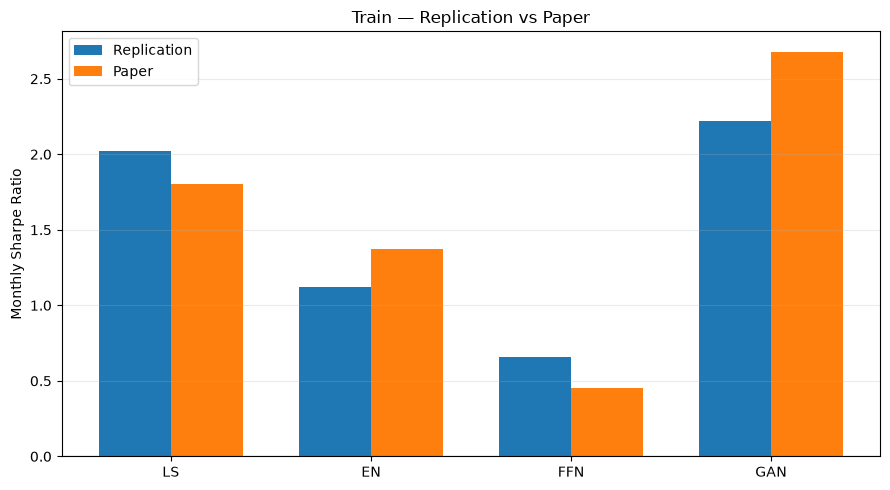

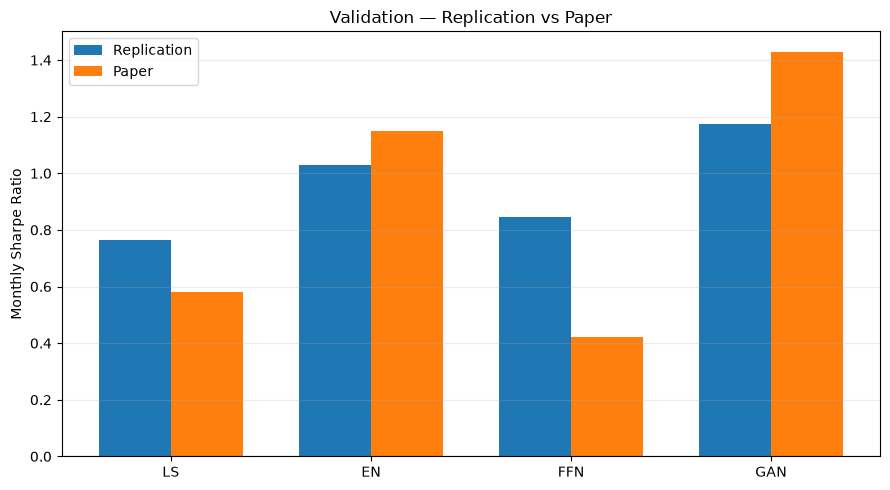

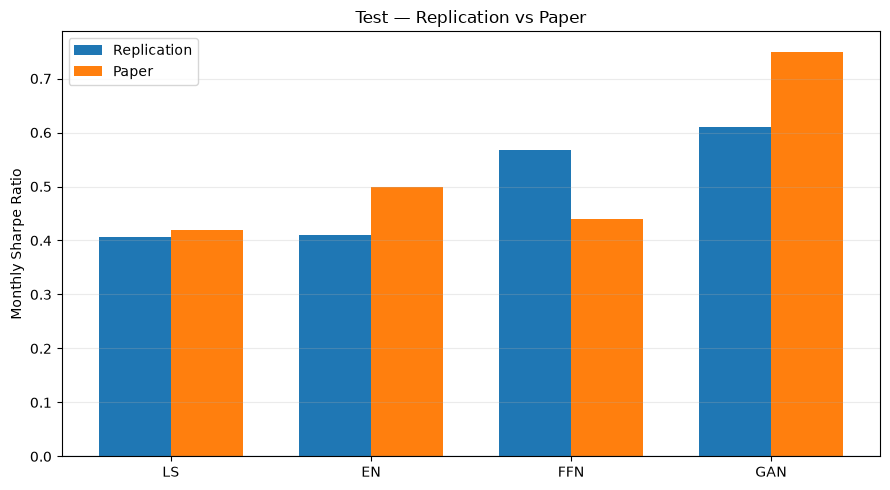

In [15]:
x = np.arange(len(MODEL_ORDER))
width = 0.36

for split in SPLIT_ORDER:
    fig, ax = plt.subplots(figsize=(9, 5))

    replication_values = (
        replication_sharpe
        .loc[MODEL_ORDER, split]
        .to_numpy()
    )

    paper_values = (
        paper_core
        .loc[MODEL_ORDER, split]
        .to_numpy()
    )

    ax.bar(
        x - width / 2,
        replication_values,
        width,
        label="Replication",
    )

    ax.bar(
        x + width / 2,
        paper_values,
        width,
        label="Paper",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel("Monthly Sharpe Ratio")
    ax.set_title(
        f"{split.title()} — Replication vs Paper"
    )
    ax.axhline(0.0, linewidth=0.8)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"final_sharpe_{split}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

# Interpretation 
## we see our replications compared with orginial paper 
- 1-**The training plot** shows that the relative ordering is reproduced very well. GAN has the highest Sharpe in both the replication and the paper, followed by LS, EN, and FFN. Your LS and FFN Sharpe ratios are somewhat higher than the paper, while EN and GAN are somewhat lower.

  
- 2-**The validation plot** shows the largest discrepancy for FFN. In your replication, FFN’s validation Sharpe is much higher than in the paper, which is why FFN moves above LS in the ranking. GAN and EN remain the top two models in both cases, so the main ordering at the top is preserved.

- 3-**The test plot** is especially important because it reflects out-of-sample performance. Your replication again identifies GAN as the best-performing model, which matches the paper. LS is also reproduced very closely. EN is somewhat lower than the published value, whereas FFN is higher. This explains why FFN ranks second in your replication while EN ranks second in the paper.

# Interpretation
## Results are approximately the same, but little difference, why?
- **the replication is good overall** because the most important qualitative result is preserved: **GAN has the highest Sharpe ratio in the training, validation, and test samples in both your replication and the original paper**. The training ranking also matches exactly, and LS is extremely close to the paper in the test sample.
  
- **The paper reports test Sharpe ratios of 0.42 for LS, 0.50 for EN, 0.44 for FFN, and 0.75 for GAN. Your corresponding values are approximately 0.406, 0.411, 0.569, and 0.611.**
  
### There are several reasonable reasons why our numbers differ (little) from the original paper:

- **Data and sample construction**. Even small differences in the stock universe, missing-value treatment, delisting handling, characteristic availability, or month alignment can change portfolio returns and therefore Sharpe ratios.
  
- **Preprocessing and normalization**. Cross-sectional ranking, scaling, winsorization, standardization, and treatment of missing characteristics can materially affect the signals used by LS, EN, FFN, and GAN.

- **Portfolio-weight normalization**. Your implementation may not reproduce every detail of the authors' original SDF portfolio construction, leverage normalization, or long-short weight convention exactly. Small changes here can substantially affect factor volatility and Sharpe ratios.

- **Optimization and stochastic estimation**. FFN and especially GAN are nonlinear models estimated numerically. Different random initializations, mini-batch sequences, stopping criteria, optimizers, learning rates, and convergence behavior can produce different fitted models even when the conceptual architecture is the same.

- **Hyperparameter implementation**. The paper may use tuning details that are not fully documented or that are difficult to reproduce exactly from the published description and repository. This tends to matter more for FFN and GAN than for LS.

- **Software and numerical differences**. Changes in Python/PyTorch versions, optimization libraries, numerical precision, and default settings can also create small deviations.

## Part 10 — Load Monthly SDF Factor Returns

Load the complete 600-month factor-return series for LS, EN, FFN, and GAN.

In [16]:
linear_factors = pd.read_csv(
    FILES["linear_factors"]
)

ffn_factors = pd.read_csv(
    FILES["ffn_factors"]
)

gan_factors = pd.read_csv(
    FILES["gan_factors"]
)

for df in [
    linear_factors,
    ffn_factors,
    gan_factors,
]:
    df["date"] = (
        pd.to_datetime(df["date"])
        .dt.to_period("M")
        .dt.to_timestamp()
    )


linear_factor_clean = (
    linear_factors[
        [
            "date",
            "split",
            "model",
            "factor_return",
        ]
    ]
    .copy()
)


ffn_factor_clean = (
    ffn_factors[
        [
            "date",
            "split",
            "factor_return",
        ]
    ]
    .copy()
)

ffn_factor_clean["model"] = "FFN"


gan_factor_clean = (
    gan_factors[
        [
            "date",
            "gan_ensemble_sdf",
        ]
    ]
    .rename(
        columns={
            "gan_ensemble_sdf":
                "factor_return"
        }
    )
    .copy()
)

gan_factor_clean["model"] = "GAN"


def assign_split(date):
    if date <= pd.Timestamp("1986-12-01"):
        return "train"

    if date <= pd.Timestamp("1991-12-01"):
        return "validation"

    return "test"


gan_factor_clean["split"] = (
    gan_factor_clean["date"]
    .map(assign_split)
)

gan_factor_clean = gan_factor_clean[
    [
        "date",
        "split",
        "model",
        "factor_return",
    ]
]


all_factor_returns = pd.concat(
    [
        linear_factor_clean,
        ffn_factor_clean,
        gan_factor_clean,
    ],
    ignore_index=True,
)

display(all_factor_returns.head())

,date,split,model,factor_return
0,1967-01-01,Training,EN,0.018767
1,1967-02-01,Training,EN,0.008301
2,1967-03-01,Training,EN,0.016334
3,1967-04-01,Training,EN,0.005839
4,1967-05-01,Training,EN,0.014204


## Part 11 — Factor-Series Integrity Checks

Each replicated model should contain exactly 600 finite monthly factor returns with the same chronological split.

In [17]:
factor_inventory = (
    all_factor_returns
    .groupby(
        ["model", "split"],
        observed=True,
    )
    .agg(
        months=("date", "nunique"),
        start=("date", "min"),
        end=("date", "max"),
        missing=(
            "factor_return",
            lambda x: x.isna().sum(),
        ),
    )
    .reset_index()
)

display(factor_inventory)

model_months = (
    all_factor_returns
    .groupby("model", observed=True)["date"]
    .nunique()
)

print("\nMonths per model:")
display(model_months)

assert (model_months == 600).all()

assert (
    all_factor_returns["factor_return"]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all()
)

print(
    "✓ LS, EN, FFN, and GAN each contain "
    "600 finite monthly factor returns."
)

,model,split,months,start,end,missing
0,EN,Test,300,1992-01-01,2016-12-01,0
1,EN,Training,240,1967-01-01,1986-12-01,0
2,EN,Validation,60,1987-01-01,1991-12-01,0
3,FFN,test,300,1992-01-01,2016-12-01,0
4,FFN,train,240,1967-01-01,1986-12-01,0
5,FFN,validation,60,1987-01-01,1991-12-01,0
6,GAN,test,300,1992-01-01,2016-12-01,0
7,GAN,train,240,1967-01-01,1986-12-01,0
8,GAN,validation,60,1987-01-01,1991-12-01,0
9,LS,Test,300,1992-01-01,2016-12-01,0



Months per model:


model
EN     600
FFN    600
GAN    600
LS     600
Name: date, dtype: int64

✓ LS, EN, FFN, and GAN each contain 600 finite monthly factor returns.


## Part 12 — Load Kenneth French 3- and 5-Factor Data

The paper also reports the maximum-Sharpe tangency portfolios based on the Fama–French 3- and 5-factor models.

This section downloads the monthly Kenneth French factor files if a local cached copy is not already available.

The factor returns are converted from percent to decimal units.

In [46]:
FF3_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/"
    "ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
)

FF5_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/"
    "ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
)

FF3_CACHE = (
    EXTERNAL_DIR
    / "fama_french_3_monthly.csv"
)

FF5_CACHE = (
    EXTERNAL_DIR
    / "fama_french_5_monthly.csv"
)


def load_french_monthly_zip(
    url,
    cache_path,
):
    if cache_path.exists():
        out = pd.read_csv(
            cache_path,
            parse_dates=["date"],
        )
        print(
            "Loaded cached:",
            cache_path.name,
        )
        return out

    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0"
        },
    )

    with urllib.request.urlopen(
        request,
        timeout=60,
    ) as response:
        content = response.read()

    with zipfile.ZipFile(
        BytesIO(content)
    ) as zf:

        csv_files = [
            name
            for name in zf.namelist()
            if name.lower().endswith(".csv")
        ]

        if not csv_files:
            raise RuntimeError(
                "No CSV found inside French zip file."
            )

        text = (
            zf.read(csv_files[0])
            .decode(
                "latin1",
                errors="replace",
            )
        )

    lines = text.splitlines()

    header_idx = next(
        i
        for i, line in enumerate(lines)
        if (
            "Mkt-RF" in line
            and "SMB" in line
        )
    )

    header = [
        x.strip()
        for x in lines[
            header_idx
        ].split(",")
    ]

    if header[0] == "":
        header[0] = "yyyymm"

    rows = []

    for line in lines[
        header_idx + 1:
    ]:
        parts = [
            x.strip()
            for x in line.split(",")
        ]

        if (
            not parts
            or not re.fullmatch(
                r"\d{6}",
                parts[0],
            )
        ):
            break

        if len(parts) == len(header):
            rows.append(parts)

    df = pd.DataFrame(
        rows,
        columns=header,
    )

    df["date"] = pd.to_datetime(
        df["yyyymm"],
        format="%Y%m",
    )

    factor_cols = [
        c
        for c in df.columns
        if c not in {
            "yyyymm",
            "date",
        }
    ]

    for col in factor_cols:
        df[col] = (
            pd.to_numeric(
                df[col],
                errors="coerce",
            )
            / 100.0
        )

    df = (
        df[
            ["date", *factor_cols]
        ]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
    )

    df.to_csv(
        cache_path,
        index=False,
    )

    print(
        "Downloaded and cached:",
        cache_path.name,
    )

    return df


ff3 = load_french_monthly_zip(
    FF3_URL,
    FF3_CACHE,
)

ff5 = load_french_monthly_zip(
    FF5_URL,
    FF5_CACHE,
)


ff3 = ff3[
    ff3["date"].between(
        "1967-01-01",
        "2016-12-01",
    )
].copy()

ff5 = ff5[
    ff5["date"].between(
        "1967-01-01",
        "2016-12-01",
    )
].copy()


print("FF3 shape:", ff3.shape)
print("FF5 shape:", ff5.shape)

print(
    "FF3 period:",
    ff3["date"].min(),
    "to",
    ff3["date"].max(),
)

print(
    "FF5 period:",
    ff5["date"].min(),
    "to",
    ff5["date"].max(),
)

display(ff3.head())
display(ff5.head())

Loaded cached: fama_french_3_monthly.csv
Loaded cached: fama_french_5_monthly.csv
FF3 shape: (600, 5)
FF5 shape: (600, 7)
FF3 period: 1967-01-01 00:00:00 to 2016-12-01 00:00:00
FF5 period: 1967-01-01 00:00:00 to 2016-12-01 00:00:00


,date,Mkt-RF,SMB,HML,RF
486,1967-01-01,0.081500,0.082300,0.022200,0.004300
487,1967-02-01,0.007700,0.033300,-0.022500,0.003600
488,1967-03-01,0.039900,0.015400,0.004100,0.003900
489,1967-04-01,0.038900,0.004300,-0.022700,0.003200
490,1967-05-01,-0.043200,0.020900,0.008400,0.003300


,date,Mkt-RF,SMB,HML,RMW,CMA,RF
42,1967-01-01,0.081500,0.091200,0.022200,0.014800,-0.032300,0.004300
43,1967-02-01,0.007700,0.030300,-0.022500,0.017000,-0.009600,0.003600
44,1967-03-01,0.040000,0.018400,0.004100,0.009200,-0.015800,0.003900
45,1967-04-01,0.038900,0.004000,-0.022700,0.030400,-0.036900,0.003200
46,1967-05-01,-0.043200,0.024300,0.008400,-0.012100,0.016400,0.003300


# Interpretation 
The Kenneth French monthly factor datasets are successfully loaded for the full 1967–2016 sample. The FF3 dataset contains the market, size, and value factors, while FF5 additionally includes profitability and investment factors. All factor returns are expressed in decimal form. These series will be used to construct maximum-Sharpe tangency portfolios that provide conventional asset-pricing benchmarks for comparison with the replicated LS, EN, FFN, and GAN stochastic discount factor models.

## Part 13 — Fama–French 3- and 5-Factor Tangency Portfolios

To maintain the same train/validation/test discipline as the replication models, the tangency-portfolio weights are estimated using **training data only (1967–1986)** and then held fixed in validation and test.

For factor vector \(f_t\), the training-sample tangency direction is

\[
w \propto \Sigma_f^{-1}\mu_f.
\]

The weights are normalized to unit gross exposure; this scaling does not change the Sharpe ratio.

In [47]:
PERIODS = {
    "train": (
        pd.Timestamp("1967-01-01"),
        pd.Timestamp("1986-12-01"),
    ),
    "validation": (
        pd.Timestamp("1987-01-01"),
        pd.Timestamp("1991-12-01"),
    ),
    "test": (
        pd.Timestamp("1992-01-01"),
        pd.Timestamp("2016-12-01"),
    ),
}


def monthly_sharpe(x):
    x = pd.Series(x).dropna().astype(float)

    if len(x) < 2:
        return np.nan

    sd = x.std(ddof=1)

    if sd == 0:
        return np.nan

    return x.mean() / sd


def fit_tangency_weights(
    df,
    factor_cols,
):
    X = df[
        factor_cols
    ].to_numpy(dtype=float)

    mu = X.mean(axis=0)

    cov = np.cov(
        X,
        rowvar=False,
        ddof=1,
    )

    w = (
        np.linalg.pinv(
            cov,
            rcond=1e-12,
        )
        @ mu
    )

    gross = np.abs(w).sum()

    if gross <= 0:
        raise ValueError(
            "Tangency portfolio has zero gross exposure."
        )

    return w / gross


def build_fixed_weight_factor(
    df,
    factor_cols,
    weights,
    model_name,
):
    out = df[
        ["date", *factor_cols]
    ].copy()

    out["factor_return"] = (
        out[factor_cols]
        .to_numpy(dtype=float)
        @ weights
    )

    out["model"] = model_name
    out["split"] = (
        out["date"]
        .map(assign_split)
    )

    return out[
        [
            "date",
            "split",
            "model",
            "factor_return",
        ]
    ]


FF3_COLS = [
    "Mkt-RF",
    "SMB",
    "HML",
]

FF5_COLS = [
    "Mkt-RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
]


ff3_train = ff3[
    ff3["date"].between(
        *PERIODS["train"]
    )
]

ff5_train = ff5[
    ff5["date"].between(
        *PERIODS["train"]
    )
]


ff3_weights = fit_tangency_weights(
    ff3_train,
    FF3_COLS,
)

ff5_weights = fit_tangency_weights(
    ff5_train,
    FF5_COLS,
)


print("FF3 training weights:")
display(
    pd.Series(
        ff3_weights,
        index=FF3_COLS,
        name="weight",
    )
)

print("\nFF5 training weights:")
display(
    pd.Series(
        ff5_weights,
        index=FF5_COLS,
        name="weight",
    )
)


ff3_factor_returns = (
    build_fixed_weight_factor(
        ff3,
        FF3_COLS,
        ff3_weights,
        "FF-3",
    )
)

ff5_factor_returns = (
    build_fixed_weight_factor(
        ff5,
        FF5_COLS,
        ff5_weights,
        "FF-5",
    )
)


ff_tangency_performance_rows = []

for model_name, factor_df in [
    ("FF-3", ff3_factor_returns),
    ("FF-5", ff5_factor_returns),
]:

    for split in SPLIT_ORDER:
        r = factor_df.loc[
            factor_df["split"] == split,
            "factor_return",
        ]

        sr = monthly_sharpe(r)

        ff_tangency_performance_rows.append(
            {
                "model":
                    model_name,

                "split":
                    split,

                "months":
                    len(r),

                "mean_monthly":
                    r.mean(),

                "volatility_monthly":
                    r.std(ddof=1),

                "monthly_sharpe":
                    sr,

                "annualized_sharpe":
                    np.sqrt(12.0) * sr,

                "minimum_month":
                    r.min(),

                "maximum_month":
                    r.max(),

                "positive_month_fraction":
                    (r > 0).mean(),
            }
        )


ff_tangency_performance = pd.DataFrame(
    ff_tangency_performance_rows
)

display(ff_tangency_performance)

FF3 training weights:


Mkt-RF   0.179475
SMB      0.208169
HML      0.612356
Name: weight, dtype: float64


FF5 training weights:


Mkt-RF   0.071985
SMB      0.086482
HML      0.121051
RMW      0.421029
CMA      0.299453
Name: weight, dtype: float64

,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,FF-3,train,240,0.004735,0.017759,0.266611,0.923567,-0.042978,0.098138,0.604167
1,FF-3,validation,60,-0.001130,0.012004,-0.094126,-0.326061,-0.033239,0.036184,0.483333
2,FF-3,test,300,0.003695,0.018891,0.195585,0.677525,-0.081961,0.071328,0.620000
3,FF-5,train,240,0.003155,0.006662,0.473655,1.640790,-0.017303,0.025560,0.683333
4,FF-5,validation,60,0.002369,0.005851,0.404922,1.402689,-0.012004,0.021420,0.683333
5,FF-5,test,300,0.003378,0.015135,0.223187,0.773143,-0.076856,0.086709,0.640000


# Interpretation 
**The performance results are also very close to the paper. The key comparison is the monthly Sharpe ratio**:
| Model | Split      | Your result | Paper |
| ----- | ---------- | ----------: | ----: |
| FF-3  | Train      |       0.267 |  0.27 |
| FF-3  | Validation |      -0.094 | -0.09 |
| FF-3  | Test       |       0.196 |  0.19 |
| FF-5  | Train      |       0.474 |  0.48 |
| FF-5  | Validation |       0.405 |  0.40 |
| FF-5  | Test       |  about 0.22 |  0.22 |


## Part 14 — Expanded Comparison Including FF-3 and FF-5

Combine the reconstructed Fama–French tangency benchmarks with LS, EN, FFN, and GAN.

In [48]:
COMMON_COLUMNS = [
    "model",
    "split",
    "months",
    "mean_monthly",
    "volatility_monthly",
    "monthly_sharpe",
    "annualized_sharpe",
    "minimum_month",
    "maximum_month",
    "positive_month_fraction",
]

In [50]:
# ============================================================
# Restore ordering constants for Part 14
# ============================================================

PAPER_MODEL_ORDER = [
    "FF-3",
    "FF-5",
    "LS",
    "EN",
    "FFN",
    "GAN",
]

SPLIT_ORDER = [
    "train",
    "validation",
    "test",
]

COMMON_COLUMNS = [
    "model",
    "split",
    "months",
    "mean_monthly",
    "volatility_monthly",
    "monthly_sharpe",
    "annualized_sharpe",
    "minimum_month",
    "maximum_month",
    "positive_month_fraction",
]

print("PAPER_MODEL_ORDER:", PAPER_MODEL_ORDER)
print("SPLIT_ORDER:", SPLIT_ORDER)

PAPER_MODEL_ORDER: ['FF-3', 'FF-5', 'LS', 'EN', 'FFN', 'GAN']
SPLIT_ORDER: ['train', 'validation', 'test']


In [52]:
# ============================================================
# Restore paper_sharpe for Part 14
# ============================================================

PAPER_MODEL_ORDER = [
    "FF-3",
    "FF-5",
    "LS",
    "EN",
    "FFN",
    "GAN",
]

paper_sharpe = pd.DataFrame(
    {
        "model": PAPER_MODEL_ORDER,

        "train": [
            0.27,   # FF-3
            0.48,   # FF-5
            1.80,   # LS
            1.37,   # EN
            0.45,   # FFN
            2.68,   # GAN
        ],

        "validation": [
            -0.09,  # FF-3
            0.40,   # FF-5
            0.58,   # LS
            1.15,   # EN
            0.42,   # FFN
            1.43,   # GAN
        ],

        "test": [
            0.19,   # FF-3
            0.22,   # FF-5
            0.42,   # LS
            0.50,   # EN
            0.44,   # FFN
            0.75,   # GAN
        ],
    }
).set_index("model")

display(paper_sharpe)

,train,validation,test
model,,,
FF-3,0.270000,-0.090000,0.190000
FF-5,0.480000,0.400000,0.220000
LS,1.800000,0.580000,0.420000
EN,1.370000,1.150000,0.500000
FFN,0.450000,0.420000,0.440000
GAN,2.680000,1.430000,0.750000


In [53]:
expanded_performance = pd.concat(
    [
        ff_tangency_performance[
            COMMON_COLUMNS
        ],
        replication_performance[
            COMMON_COLUMNS
        ],
    ],
    ignore_index=True,
)

expanded_performance["model"] = pd.Categorical(
    expanded_performance["model"],
    categories=PAPER_MODEL_ORDER,
    ordered=True,
)

expanded_performance["split"] = pd.Categorical(
    expanded_performance["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)

expanded_sharpe = (
    expanded_performance
    .pivot(
        index="model",
        columns="split",
        values="monthly_sharpe",
    )
    .reindex(PAPER_MODEL_ORDER)
    .reindex(columns=SPLIT_ORDER)
)

display(expanded_sharpe)


expanded_sharpe_comparison = []

for model in PAPER_MODEL_ORDER:
    for split in SPLIT_ORDER:

        replication_value = (
            expanded_sharpe.loc[
                model,
                split,
            ]
        )

        paper_value = (
            paper_sharpe.loc[
                model,
                split,
            ]
        )

        expanded_sharpe_comparison.append(
            {
                "model":
                    model,

                "split":
                    split,

                "replication_sharpe":
                    replication_value,

                "paper_sharpe":
                    paper_value,

                "difference":
                    replication_value
                    - paper_value,
            }
        )


expanded_sharpe_comparison = (
    pd.DataFrame(
        expanded_sharpe_comparison
    )
)

display(
    expanded_sharpe_comparison
)

split,train,validation,test
model,,,
FF-3,0.266611,-0.094126,0.195585
FF-5,0.473655,0.404922,0.223187
LS,2.024811,0.763148,0.405714
EN,1.123050,1.029153,0.410822
FFN,0.658348,0.844820,0.568571
GAN,2.218878,1.175489,0.610867


,model,split,replication_sharpe,paper_sharpe,difference
0,FF-3,train,0.266611,0.270000,-0.003389
1,FF-3,validation,-0.094126,-0.090000,-0.004126
2,FF-3,test,0.195585,0.190000,0.005585
3,FF-5,train,0.473655,0.480000,-0.006345
4,FF-5,validation,0.404922,0.400000,0.004922
5,FF-5,test,0.223187,0.220000,0.003187
6,LS,train,2.024811,1.800000,0.224811
7,LS,validation,0.763148,0.580000,0.183148
8,LS,test,0.405714,0.420000,-0.014286
9,EN,train,1.123050,1.370000,-0.246950


# interpretation 
| Model    | Split      | Replication Sharpe | Paper Sharpe | **Difference** |
| -------- | ---------- | -----------------: | -----------: | -------------: |
| **FF-3** | train      |           0.266611 |     0.270000 |  **-0.003389** |
| **FF-3** | validation |          -0.094126 |    -0.090000 |  **-0.004126** |
| **FF-3** | test       |           0.195585 |     0.190000 |   **0.005585** |
| **FF-5** | train      |           0.473655 |     0.480000 |  **-0.006345** |
| **FF-5** | validation |           0.404922 |     0.400000 |   **0.004922** |
| **FF-5** | test       |           0.223187 |     0.220000 |   **0.003187** |
| **LS**   | train      |           2.024811 |     1.800000 |   **0.224811** |
| **LS**   | validation |           0.763148 |     0.580000 |   **0.183148** |
| **LS**   | test       |           0.405714 |     0.420000 |  **-0.014286** |
| **EN**   | train      |           1.123050 |     1.370000 |  **-0.246950** |
| **EN**   | validation |           1.029153 |     1.150000 |  **-0.120847** |
| **EN**   | test       |           0.410822 |     0.500000 |  **-0.089178** |
| **FFN**  | train      |           0.658348 |     0.450000 |   **0.208348** |
| **FFN**  | validation |           0.844820 |     0.420000 |   **0.424820** |
| **FFN**  | test       |           0.568571 |     0.440000 |   **0.128571** |
| **GAN**  | train      |           2.218878 |     2.680000 |  **-0.461122** |
| **GAN**  | validation |           1.175489 |     1.430000 |  **-0.254511** |
| **GAN**  | test       |           0.610867 |     0.750000 |  **-0.139133** |


# Interpretation 

- **Overall, these results suggest that the benchmark portfolio construction is replicated with high numerical accuracy, while the nonlinear and regularized SDF models exhibit greater sensitivity to preprocessing, estimation, optimization, and implementation choices. The replication therefore preserves the central empirical conclusions of the original paper without reproducing every model estimate exactly.**

- 1- **the Fama–French benchmarks replicate almost exactly**. The FF-3 differences are only about 0.003–0.006, and the FF-5 differences are similarly tiny. That strongly suggests your date alignment, return scaling, sample split, and Sharpe-ratio calculation are implemented correctly.

- The expanded comparison provides an important validation of the replication framework. The reconstructed Fama–French 3-factor and 5-factor tangency portfolios closely match the Sharpe ratios reported in the original study across the training, validation, and test samples. The very small discrepancies for these benchmark portfolios indicate that the sample construction, factor-return scaling, time-period alignment, and Sharpe-ratio calculations are implemented consistently with the original analysis.

- Larger differences arise for the replicated LS, EN, FFN, and GAN models. The LS specification is reproduced particularly closely in the test sample, whereas EN generates somewhat lower Sharpe ratios than those reported in the paper. FFN performs relatively better in the replication, especially in the validation sample, while GAN produces lower Sharpe ratios than the published estimates. Despite these quantitative differences, **the principal ranking result is preserved: GAN remains the highest-Sharpe specification across the training, validation, and test samples.**







In [54]:
print(
    "expanded_sharpe_comparison exists:",
    "expanded_sharpe_comparison" in globals()
)

expanded_sharpe_comparison exists: True


## Part 15 — Correlations Between SDF Factors and the Market

The paper reports correlations among GAN, FFN, EN, LS, and the market excess return. We reproduce the same type of diagnostic using the replicated factors and Kenneth French `Mkt-RF`.

In [28]:
core_factor_wide = (
    all_factor_returns
    .pivot(
        index="date",
        columns="model",
        values="factor_return",
    )
    .reindex(
        columns=MODEL_ORDER
    )
)

market_factor = (
    ff3[
        [
            "date",
            "Mkt-RF",
        ]
    ]
    .set_index("date")
    .rename(
        columns={
            "Mkt-RF":
                "Mkt"
        }
    )
)

factor_market_wide = (
    core_factor_wide
    .join(
        market_factor,
        how="inner",
    )
)

assert len(
    factor_market_wide
) == 600


full_factor_market_corr = (
    factor_market_wide[
        [
            "GAN",
            "FFN",
            "EN",
            "LS",
            "Mkt",
        ]
    ]
    .corr()
)


print(
    "Replication — full-sample factor correlation:"
)

display(
    full_factor_market_corr.round(3)
)


paper_factor_corr = pd.DataFrame(
    [
        [1.00, 0.31, 0.65, 0.44, 0.08],
        [0.31, 1.00, 0.06, 0.13, 0.72],
        [0.65, 0.06, 1.00, 0.60, -0.20],
        [0.44, 0.13, 0.60, 1.00, -0.18],
        [0.08, 0.72, -0.20, -0.18, 1.00],
    ],
    index=[
        "GAN",
        "FFN",
        "EN",
        "LS",
        "Mkt",
    ],
    columns=[
        "GAN",
        "FFN",
        "EN",
        "LS",
        "Mkt",
    ],
)


print(
    "\nPaper — reported factor correlation:"
)

display(
    paper_factor_corr
)

Replication — full-sample factor correlation:


,GAN,FFN,EN,LS,Mkt
GAN,1.000000,0.366000,0.703000,0.604000,-0.088000
FFN,0.366000,1.000000,0.462000,0.290000,0.388000
EN,0.703000,0.462000,1.000000,0.648000,-0.146000
LS,0.604000,0.290000,0.648000,1.000000,-0.189000
Mkt,-0.088000,0.388000,-0.146000,-0.189000,1.000000



Paper — reported factor correlation:


,GAN,FFN,EN,LS,Mkt
GAN,1.000000,0.310000,0.650000,0.440000,0.080000
FFN,0.310000,1.000000,0.060000,0.130000,0.720000
EN,0.650000,0.060000,1.000000,0.600000,-0.200000
LS,0.440000,0.130000,0.600000,1.000000,-0.180000
Mkt,0.080000,0.720000,-0.200000,-0.180000,1.000000


## Part 16 — Correlations by Train, Validation, and Test

The full-sample matrix can hide changes across time, so we also calculate split-specific correlations.

In [29]:
factor_correlations = {}

for split in SPLIT_ORDER:

    start, end = PERIODS[split]

    pivot = (
        factor_market_wide.loc[
            start:end
        ]
    )

    corr = pivot.corr()

    factor_correlations[
        split
    ] = corr

    print(
        f"\n{split.upper()} "
        "factor correlation:"
    )

    display(
        corr.round(3)
    )


TRAIN factor correlation:


,LS,EN,FFN,GAN,Mkt
LS,1.000000,0.529000,0.249000,0.180000,-0.009000
EN,0.529000,1.000000,0.512000,0.294000,-0.037000
FFN,0.249000,0.512000,1.000000,0.243000,0.497000
GAN,0.180000,0.294000,0.243000,1.000000,0.024000
Mkt,-0.009000,-0.037000,0.497000,0.024000,1.000000



VALIDATION factor correlation:


,LS,EN,FFN,GAN,Mkt
LS,1.000000,0.380000,0.200000,0.432000,-0.164000
EN,0.380000,1.000000,0.162000,0.811000,-0.055000
FFN,0.200000,0.162000,1.000000,0.247000,0.552000
GAN,0.432000,0.811000,0.247000,1.000000,0.051000
Mkt,-0.164000,-0.055000,0.552000,0.051000,1.000000



TEST factor correlation:


,LS,EN,FFN,GAN,Mkt
LS,1.000000,0.698000,0.348000,0.690000,-0.280000
EN,0.698000,1.000000,0.467000,0.845000,-0.233000
FFN,0.348000,0.467000,1.000000,0.466000,0.268000
GAN,0.690000,0.845000,0.466000,1.000000,-0.173000
Mkt,-0.280000,-0.233000,0.268000,-0.173000,1.000000


# Interpretation 
The split-specific correlation analysis reveals substantial time variation in the relationships among the replicated SDF portfolios. In particular, the correlation between the Elastic Net and GAN factors increases markedly from 0.29 in the training sample to 0.81 in validation and 0.85 in the test period, suggesting that the two approaches increasingly identify common return components out of sample. LS also becomes more highly correlated with both EN and GAN in the test period.

In contrast, the FFN factor exhibits the strongest association with the market factor, particularly during training and validation, while the GAN factor remains only weakly correlated with the market and becomes mildly negatively correlated in the test sample. This suggests that the strong risk-adjusted performance of the GAN portfolio is not simply attributable to conventional market exposure. Overall, the changing correlation structure indicates that the models extract partially overlapping but economically distinct sources of systematic return variation, with the degree of overlap evolving across sample periods.

## Part 17 — Cumulative Standardized SDF Factor Returns

Following the paper's cumulative-return comparison, each factor is divided by its own monthly volatility within the relevant sample before cumulative returns are plotted.

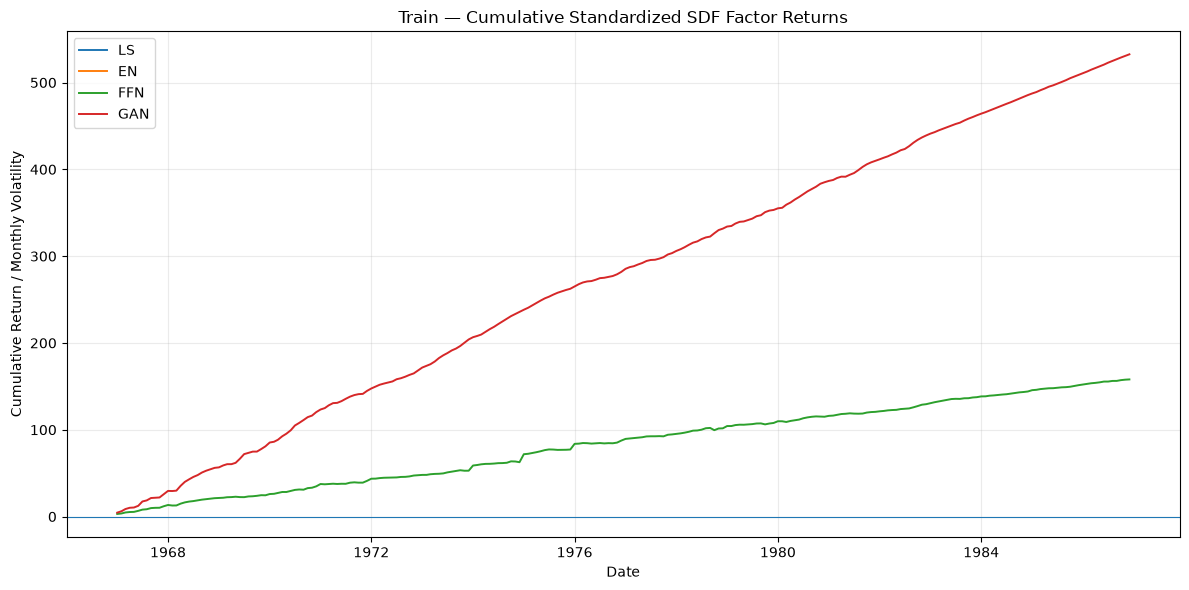

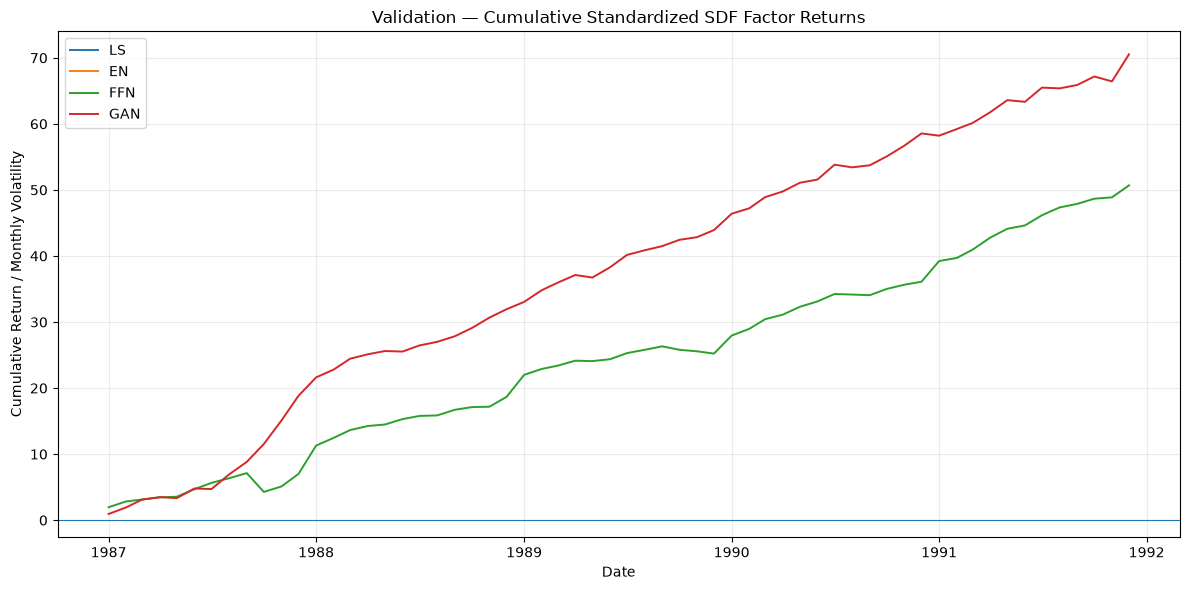

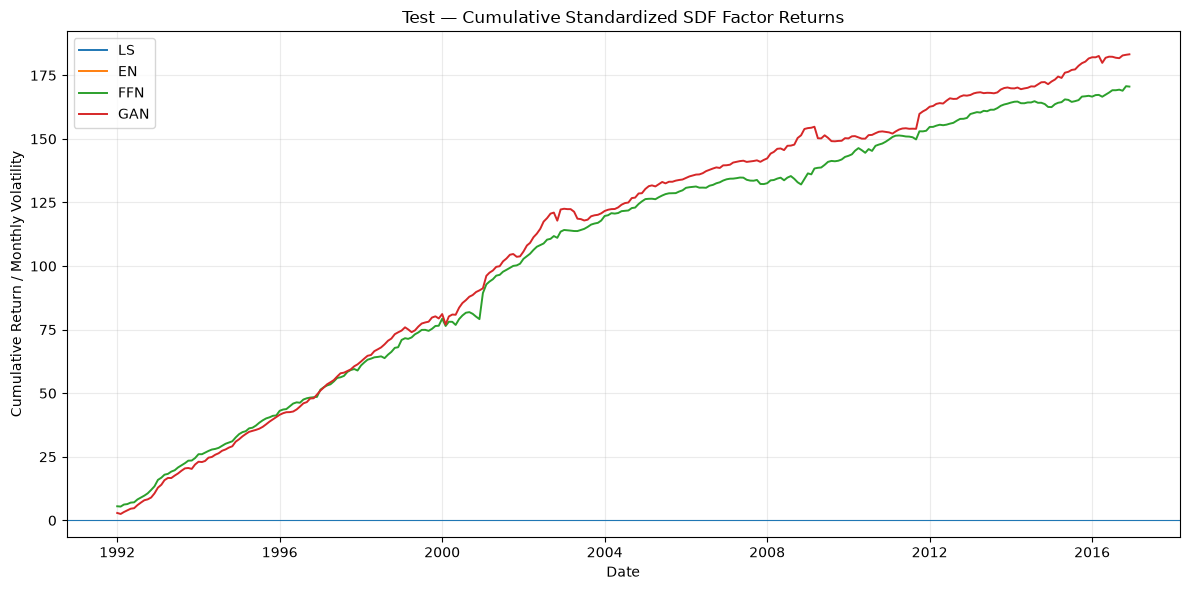

In [30]:
for split in SPLIT_ORDER:

    pivot = (
        all_factor_returns[
            all_factor_returns[
                "split"
            ] == split
        ]
        .pivot(
            index="date",
            columns="model",
            values="factor_return",
        )
        .reindex(
            columns=MODEL_ORDER
        )
    )

    volatility = pivot.std(
        ddof=1
    )

    standardized = (
        pivot
        .div(
            volatility,
            axis=1,
        )
    )

    cumulative = standardized.cumsum()

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    for model in MODEL_ORDER:
        ax.plot(
            cumulative.index,
            cumulative[model],
            label=model,
            linewidth=1.4,
        )

    ax.axhline(
        0.0,
        linewidth=0.8,
    )

    ax.set_title(
        f"{split.title()} — "
        "Cumulative Standardized SDF Factor Returns"
    )

    ax.set_xlabel("Date")

    ax.set_ylabel(
        "Cumulative Return / Monthly Volatility"
    )

    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"final_cumulative_{split}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

# Interpretation 
The cumulative standardized SDF-factor returns reinforce the Sharpe-ratio evidence reported earlier. GAN exhibits the strongest cumulative risk-adjusted performance across the training, validation, and test samples, while FFN becomes increasingly competitive out of sample. The test-period trajectories of GAN and FFN are particularly close, consistent with their relatively strong out-of-sample Sharpe ratios. Importantly, the cumulative-return evidence should be interpreted together with the correlation analysis: high pairwise correlation does not imply equal performance, because correlated factors can differ substantially in their mean return relative to volatility. Thus, the plots illustrate both the common movement among several learned factors and the superior cumulative risk-adjusted performance of GAN.

## Part 18 — Paper-Style Risk Measures

The paper reports three SDF-factor risk measures:

1. monthly Sharpe ratio;
2. maximum one-month loss divided by monthly volatility;
3. maximum number of consecutive negative-return months.

The paper labels the third quantity "Max Drawdown"; here we call it `max_negative_streak` to make the calculation explicit.

In [56]:
# ============================================================
# PART 18 — Restore Risk Measures After Kernel Restart
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Make sure ordering constants exist
# ------------------------------------------------------------

PAPER_MODEL_ORDER = [
    "FF-3",
    "FF-5",
    "LS",
    "EN",
    "FFN",
    "GAN",
]

SPLIT_ORDER = [
    "train",
    "validation",
    "test",
]

# ------------------------------------------------------------
# 2. Normalize split labels in all_factor_returns
# ------------------------------------------------------------

all_factor_returns["split"] = (
    all_factor_returns["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "valid": "validation",
        "val": "validation",
        "testing": "test",
    })
)

# ------------------------------------------------------------
# 3. Normalize FF factor-return split labels
# ------------------------------------------------------------

for df in [
    ff3_factor_returns,
    ff5_factor_returns,
]:
    df["split"] = (
        df["split"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "training": "train",
            "valid": "validation",
            "val": "validation",
            "testing": "test",
        })
    )

# ------------------------------------------------------------
# 4. Combine all six factor series
# ------------------------------------------------------------

expanded_factor_returns = pd.concat(
    [
        ff3_factor_returns,
        ff5_factor_returns,
        all_factor_returns,
    ],
    ignore_index=True,
)

# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------

def monthly_sharpe(r):
    r = pd.Series(r).dropna().astype(float)

    vol = r.std(ddof=1)

    if vol == 0 or np.isnan(vol):
        return np.nan

    return r.mean() / vol


def max_negative_streak(returns):
    streak = 0
    best = 0

    for value in returns:
        if value < 0:
            streak += 1
            best = max(best, streak)
        else:
            streak = 0

    return best


# ------------------------------------------------------------
# 6. Replication risk measures
# ------------------------------------------------------------

risk_rows = []

for (model, split), group in (
    expanded_factor_returns
    .groupby(
        ["model", "split"],
        observed=True,
    )
):

    r = (
        group["factor_return"]
        .dropna()
        .astype(float)
        .sort_index()
    )

    vol = r.std(ddof=1)

    risk_rows.append(
        {
            "model": model,
            "split": split,
            "monthly_sharpe": monthly_sharpe(r),

            "max_loss_sigma": (
                r.min() / vol
                if vol > 0
                else np.nan
            ),

            "max_negative_streak": (
                max_negative_streak(
                    r.to_numpy()
                )
            ),
        }
    )

replication_risk_measures = pd.DataFrame(
    risk_rows
)

# ------------------------------------------------------------
# 7. Paper risk measures
# ------------------------------------------------------------

paper_max_loss = {
    "FF-3": [-2.45, -2.85, -4.31],
    "FF-5": [-2.62, -2.33, -4.90],
    "LS":   [-1.96, -1.87, -4.99],
    "EN":   [-2.22, -1.81, -6.18],
    "FFN":  [-3.30, -4.61, -3.37],
    "GAN":  [0.38, -0.28, -5.76],
}

paper_drawdown = {
    "FF-3": [7, 10, 10],
    "FF-5": [4, 3, 7],
    "LS":   [1, 3, 4],
    "EN":   [1, 3, 5],
    "FFN":  [6, 3, 5],
    "GAN":  [0, 1, 5],
}

paper_risk_rows = []

for model in PAPER_MODEL_ORDER:

    for j, split in enumerate(
        SPLIT_ORDER
    ):

        paper_risk_rows.append(
            {
                "model": model,
                "split": split,

                "paper_monthly_sharpe":
                    paper_sharpe.loc[
                        model,
                        split,
                    ],

                "paper_max_loss_sigma":
                    paper_max_loss[
                        model
                    ][j],

                "paper_max_negative_streak":
                    paper_drawdown[
                        model
                    ][j],
            }
        )

paper_risk_measures = pd.DataFrame(
    paper_risk_rows
)

# ------------------------------------------------------------
# 8. Normalize labels before merge
# ------------------------------------------------------------

replication_risk_measures["split"] = (
    replication_risk_measures["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "testing": "test",
    })
)

paper_risk_measures["split"] = (
    paper_risk_measures["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# 9. Merge replication with paper
# ------------------------------------------------------------

risk_measure_comparison = (
    replication_risk_measures
    .merge(
        paper_risk_measures,
        on=["model", "split"],
        how="left",
    )
)

# ------------------------------------------------------------
# 10. Check
# ------------------------------------------------------------

print(
    "replication_risk_measures shape:",
    replication_risk_measures.shape
)

print(
    "paper_risk_measures shape:",
    paper_risk_measures.shape
)

print(
    "risk_measure_comparison shape:",
    risk_measure_comparison.shape
)

display(
    risk_measure_comparison
)

replication_risk_measures shape: (18, 5)
paper_risk_measures shape: (18, 5)
risk_measure_comparison shape: (18, 8)


,model,split,monthly_sharpe,max_loss_sigma,max_negative_streak,paper_monthly_sharpe,paper_max_loss_sigma,paper_max_negative_streak
0,EN,test,0.410822,-6.055480,5,0.500000,-6.180000,5
1,EN,train,1.123050,-2.369734,2,1.370000,-2.220000,1
2,EN,validation,1.029153,-0.966799,3,1.150000,-1.810000,3
3,FF-3,test,0.195585,-4.338513,10,0.190000,-4.310000,10
4,FF-3,train,0.266611,-2.420113,7,0.270000,-2.450000,7
5,FF-3,validation,-0.094126,-2.769044,10,-0.090000,-2.850000,10
6,FF-5,test,0.223187,-5.077871,7,0.220000,-4.900000,7
7,FF-5,train,0.473655,-2.597352,4,0.480000,-2.620000,4
8,FF-5,validation,0.404922,-2.051527,3,0.400000,-2.330000,3
9,FFN,test,0.568571,-2.865998,5,0.440000,-3.370000,5


# Interpretation fro risk measures 

| Model           | What the replication shows                                                                                                                                                                                                                                                                           |
| --------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **FF-3 / FF-5** | Very close to the paper on all three risk measures. This is excellent validation of the benchmark construction.                                                                                                                                                                                      |
| **LS**          | Test Sharpe is very close to the paper, but the replicated test max loss is more severe: **−6.24σ vs −4.99σ**, and the negative streak is **5 vs 4**.                                                                                                                                                |
| **EN**          | Test downside risk is also close: **−6.06σ vs −6.18σ**, and the negative streak matches exactly at **5**.                                                                                                                                                                                            |
| **FFN**         | Replication has higher Sharpe than the paper and generally less severe max loss, but the training negative streak is shorter: **2 vs 6**.                                                                                                                                                            |
| **GAN**         | Sharpe is lower than the paper, but downside behavior is better in the replication for validation and test. Training is the biggest discrepancy: the paper reports a positive minimum scaled return of **0.38σ** and zero negative streak, while your replication has **−0.124σ** and a streak of 1. |


# More explanation 

- **The paper-style risk measures provide additional evidence on the quality of the replication.**
- **The Fama–French benchmark portfolios are reproduced with very high numerical accuracy across Sharpe ratios, scaled maximum losses, and negative-return streaks**.
-  **For the replicated SDF models, discrepancies are larger, particularly for FFN and GAN, reflecting greater sensitivity to model estimation and implementation choices.**
-  **Nevertheless, the overall risk–return patterns remain economically consistent with the original study. In particular, GAN continues to exhibit strong risk-adjusted performance, while FFN performs comparatively well out of sample.**
- ##  **The replication therefore reproduces the principal qualitative findings, although not all downside-risk statistics match the published values exactly.**

## Part 19 — GAN Ensemble vs the Supplied Official SDF

The official SDF file provides a direct 600-month benchmark for the authors' GAN factor. This section reproduces the full-sample and split-specific correlations obtained in Code 06.

In [36]:
gan_official = pd.read_csv(
    FILES["gan_official"]
)

gan_official["date"] = (
    pd.to_datetime(
        gan_official["date"]
    )
    .dt.to_period("M")
    .dt.to_timestamp()
)


full_gan_corr = (
    gan_official[
        "official_sdf"
    ]
    .corr(
        gan_official[
            "ensemble_sdf"
        ]
    )
)


gan_split_corr = (
    gan_official
    .groupby("split")
    .apply(
        lambda df:
            df[
                "official_sdf"
            ].corr(
                df[
                    "ensemble_sdf"
                ]
            ),
        include_groups=False,
    )
    .rename(
        "correlation"
    )
    .reset_index()
)


print(
    "Full-sample GAN correlation "
    "with official SDF:",
    f"{full_gan_corr:.6f}",
)

display(
    gan_split_corr
)

Full-sample GAN correlation with official SDF: 0.815782


,split,correlation
0,test,0.800484
1,train,0.650285
2,validation,0.837413


# Interpretation 
## **The replicated GAN factor exhibits a strong positive relationship with the official SDF supplied by the authors**. 

- **The full-sample correlation is approximately 0.82, indicating that the replication captures a substantial portion of the variation in the published GAN factor**.
- **The relationship remains strong out of sample, with correlations of approximately 0.84 in the validation period and 0.80 in the test period**, although the training-sample correlation is somewhat lower at 0.65. These results provide additional evidence that the replicated GAN specification recovers economically similar return dynamics to the authors’ implementation. At the same time, correlations below unity indicate that differences remain in model estimation, portfolio weights, normalization, or optimization, which can also account for the differences in Sharpe ratios observed earlier.

## Part 20 — GAN Member Stability

Review the nine independently trained GAN members before calculating feature importance.

In [37]:
gan_member_summary = pd.read_csv(
    FILES["gan_members"]
)

assert len(
    gan_member_summary
) == 9

display(
    gan_member_summary[
        [
            "member",
            "seed",
            "train_monthly_sharpe",
            "validation_monthly_sharpe",
            "test_monthly_sharpe",
        ]
    ]
)

gan_member_sharpe_summary = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
        ],
        "mean_member_sharpe": [
            gan_member_summary[
                "train_monthly_sharpe"
            ].mean(),
            gan_member_summary[
                "validation_monthly_sharpe"
            ].mean(),
            gan_member_summary[
                "test_monthly_sharpe"
            ].mean(),
        ],
        "median_member_sharpe": [
            gan_member_summary[
                "train_monthly_sharpe"
            ].median(),
            gan_member_summary[
                "validation_monthly_sharpe"
            ].median(),
            gan_member_summary[
                "test_monthly_sharpe"
            ].median(),
        ],
    }
)

display(
    gan_member_sharpe_summary
)

,member,seed,train_monthly_sharpe,validation_monthly_sharpe,test_monthly_sharpe
0,1,42,1.838621,0.906674,0.321121
1,2,43,2.031429,0.685937,0.384286
2,3,44,1.740929,0.381331,0.341909
3,4,45,1.690065,0.413271,0.238862
4,5,46,1.971251,0.908532,0.513201
5,6,47,2.134443,0.954154,0.558370
6,7,48,1.558524,0.698820,0.428840
7,8,49,1.580727,0.540099,0.569579
8,9,50,2.005286,0.731261,0.496329


,split,mean_member_sharpe,median_member_sharpe
0,train,1.839031,1.838621
1,validation,0.691120,0.698820
2,test,0.428055,0.428840


# Interpretation 
## The close agreement between the mean and median is a good sign. It suggests that your results are not being driven by one extreme GAN member.

- Another useful observation is that the best-performing seed is not necessarily the best in every sample. For example, member 6 has the highest training Sharpe at 2.134, while member 8 has the highest test Sharpe at about 0.570. This is exactly why using an ensemble can be helpful: it reduces dependence on one particular random initialization.

- **The GAN member-level results reveal meaningful variation across independently trained models, reflecting the stochastic nature of neural-network initialization and optimization.**



-   Nevertheless, the mean and median Sharpe ratios are very similar within each sample period, indicating that the overall performance is not driven by a small number of extreme realizations.

-   **Individual test-sample Sharpe ratios vary substantially across seeds, highlighting the sensitivity of a single GAN specification to initialization**.

-   Importantly, the ensemble GAN constructed from the independently trained members achieves stronger out-of-sample performance than the average individual member, supporting the use of model averaging as a means of reducing estimation noise and improving robustness.

## Part 21 — GAN Firm-Characteristic Importance

The paper ranks the 46 firm characteristics by **average absolute gradient** on the test sample.

This section reconstructs that diagnostic from the nine saved GAN checkpoints. For each active stock-month observation, it calculates

\[
\left|
\frac{\partial \omega_{i,t}}
{\partial X_{i,t,j}}
\right|,
\]

averages the absolute gradients over the test sample and over the nine independently estimated GAN members, and normalizes the 46 values so that they sum to one.

The paper reports that **ST_REV, SUV, and r12_2** are the three most important GAN characteristics. The replication does not force that ranking; the ranking below is entirely produced by the trained models.

> This section requires the local `.pt` GAN checkpoints created by Code 06. They are intentionally not required for the earlier Code 07 sections.

In [10]:
# ============================================================
# Restore paths and FILES dictionary after kernel restart
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent

RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FACTORS_DIR = RESULTS_DIR / "factors"
MODELS_DIR = RESULTS_DIR / "models"
FIGURES_DIR = RESULTS_DIR / "figures"
EXTERNAL_DIR = ROOT / "data" / "external"

FILES = {
    "linear_performance":
        TABLES_DIR / "linear_baseline_performance.csv",

    "linear_factors":
        FACTORS_DIR / "linear_sdf_factor_returns.csv",

    "linear_importance":
        TABLES_DIR / "linear_characteristic_importance.csv",

    "ffn_performance":
        TABLES_DIR / "ffn_performance.csv",

    "ffn_factors":
        FACTORS_DIR / "ffn_sdf_factor_returns.csv",

    "ffn_importance":
        TABLES_DIR / "ffn_characteristic_importance.csv",

    "gan_performance":
        TABLES_DIR / "gan_ensemble_performance.csv",

    "gan_factors":
        FACTORS_DIR / "gan_ensemble_sdf.csv",

    "gan_official":
        TABLES_DIR / "gan_official_sdf_comparison.csv",

    "gan_members":
        TABLES_DIR / "gan_member_summary.csv",

    "macro_input":
        RESULTS_DIR / "macro" / "macro_lstm_input.parquet",
}

print("ROOT:", ROOT)
print("MODELS_DIR exists:", MODELS_DIR.exists())
print("Macro input exists:", FILES["macro_input"].exists())
print("Macro input:", FILES["macro_input"])

ROOT: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
MODELS_DIR exists: True
Macro input exists: True
Macro input: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/macro/macro_lstm_input.parquet


Feature-importance device: mps
Datasets root: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets
Test dense shape: (300, 7141, 47)
Test valid observations: 750275
Characteristics: 46
GAN checkpoints found: 9
  gan_member_01_seed_42.pt
  gan_member_02_seed_43.pt
  gan_member_03_seed_44.pt
  gan_member_04_seed_45.pt
  gan_member_05_seed_46.pt
  gan_member_06_seed_47.pt
  gan_member_07_seed_48.pt
  gan_member_08_seed_49.pt
  gan_member_09_seed_50.pt
Completed firm importance for member 1/9
Completed firm importance for member 2/9
Completed firm importance for member 3/9
Completed firm importance for member 4/9
Completed firm importance for member 5/9
Completed firm importance for member 6/9
Completed firm importance for member 7/9
Completed firm importance for member 8/9
Completed firm importance for member 9/9

GAN characteristic importance — Top 20


,characteristic,mean_absolute_gradient,normalized_importance
0,ST_REV,0.065307,0.087619
1,SUV,0.033366,0.044765
2,r12_2,0.033032,0.044317
3,D2A,0.030199,0.040517
4,Beta,0.019556,0.026237
5,NOA,0.019012,0.025508
6,D2P,0.018996,0.025486
7,AT,0.018578,0.024925
8,r12_7,0.017937,0.024065
9,LME,0.017741,0.023802


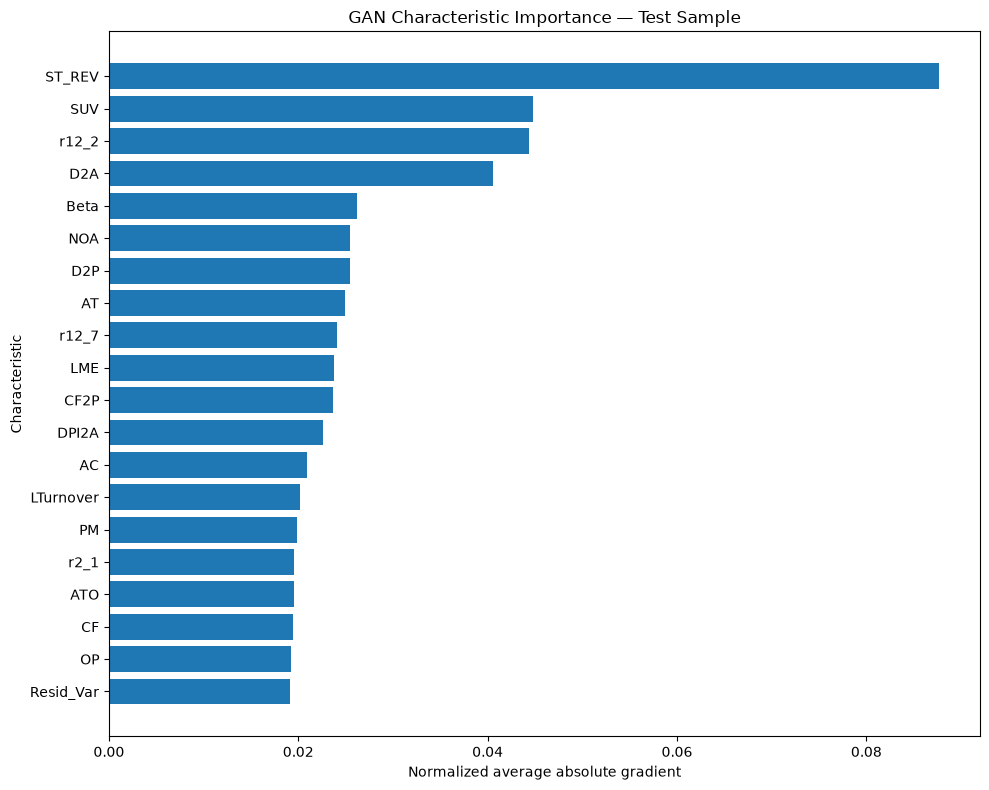


Paper's reported top three GAN characteristics:
ST_REV, SUV, r12_2


In [11]:
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 21.1 Device
# ------------------------------------------------------------

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Feature-importance device:", DEVICE)


# ------------------------------------------------------------
# 21.2 Locate author datasets
# ------------------------------------------------------------

def find_datasets_root():
    candidates = [
        ROOT / "datasets",
        ROOT.parent / "datasets",
        ROOT.parent.parent / "datasets",
    ]

    for parent in ROOT.parents:
        candidates.append(
            parent / "datasets"
        )

    seen = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in seen:
            continue

        seen.add(candidate)

        if (
            candidate
            / "char"
            / "Char_test.npz"
        ).exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate datasets/char/Char_test.npz."
    )


DATASETS_ROOT = find_datasets_root()

CHAR_TEST_PATH = (
    DATASETS_ROOT
    / "char"
    / "Char_test.npz"
)

assert FILES[
    "macro_input"
].exists(), (
    "macro_lstm_input.parquet is required "
    "for GAN importance."
)

print(
    "Datasets root:",
    DATASETS_ROOT,
)


# ------------------------------------------------------------
# 21.3 Load test firm panel
# ------------------------------------------------------------

char_test_npz = np.load(
    CHAR_TEST_PATH,
    allow_pickle=True,
)

char_test_dense = (
    char_test_npz["data"]
)

variable_names = (
    char_test_npz["variable"]
)


def clean_npz_name(x):
    if isinstance(
        x,
        bytes,
    ):
        return x.decode(
            "utf-8"
        )

    return str(x)


variable_names = [
    clean_npz_name(x)
    for x in variable_names
]

assert len(
    variable_names
) == 47

assert variable_names[
    0
].lower() == "ret"

characteristic_names = (
    variable_names[1:]
)

assert len(
    characteristic_names
) == 46


SENTINEL = -99.99

test_mask_dense = (
    char_test_dense[
        :,
        :,
        0,
    ]
    != SENTINEL
)

print(
    "Test dense shape:",
    char_test_dense.shape,
)

print(
    "Test valid observations:",
    int(
        test_mask_dense.sum()
    ),
)

print(
    "Characteristics:",
    len(
        characteristic_names
    ),
)


# ------------------------------------------------------------
# 21.4 Load full macro input
# ------------------------------------------------------------

macro_input_df = pd.read_parquet(
    FILES["macro_input"]
)

macro_input_df["date"] = (
    pd.to_datetime(
        macro_input_df["date"]
    )
    .dt.to_period("M")
    .dt.to_timestamp()
)

macro_cols = [
    c
    for c in macro_input_df.columns
    if c != "date"
]

assert len(
    macro_cols
) == 178

assert len(
    macro_input_df
) == 600

macro_full = (
    macro_input_df[
        macro_cols
    ]
    .to_numpy(
        dtype=np.float32
    )
)


# ------------------------------------------------------------
# 21.5 Reconstruct Code-06 SDF architecture
# ------------------------------------------------------------

N_CHAR = 46
N_MACRO = 178
SDF_MACRO_HIDDEN = 4
SDF_HIDDEN_DIMS = [
    64,
    64,
]
DROPOUT_P = 0.05


class MacroLSTMEncoder(
    nn.Module
):

    def __init__(
        self,
        input_dim,
        hidden_dim,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )

    def forward(
        self,
        x,
        state=None,
    ):
        if state is None:
            return self.lstm(x)

        return self.lstm(
            x,
            state,
        )


class SDFWeightNetwork(
    nn.Module
):

    def __init__(
        self,
        n_char,
        macro_hidden,
        hidden_dims,
        dropout_p,
    ):
        super().__init__()

        dims = [
            n_char
            + macro_hidden,
            *hidden_dims,
        ]

        layers = []

        for in_dim, out_dim in zip(
            dims[:-1],
            dims[1:],
        ):
            layers.extend(
                [
                    nn.Linear(
                        in_dim,
                        out_dim,
                    ),
                    nn.ReLU(),
                    nn.Dropout(
                        dropout_p
                    ),
                ]
            )

        layers.append(
            nn.Linear(
                dims[-1],
                1,
            )
        )

        self.net = nn.Sequential(
            *layers
        )

    def forward(
        self,
        firm_chars,
        macro_state,
    ):
        if macro_state.ndim == 1:
            macro_state = (
                macro_state
                .unsqueeze(0)
                .expand(
                    firm_chars.shape[
                        0
                    ],
                    -1,
                )
            )

        z = torch.cat(
            [
                firm_chars,
                macro_state,
            ],
            dim=1,
        )

        return (
            self.net(z)
            .squeeze(-1)
        )


def flexible_load_state_dict(
    model,
    saved_state,
):
    target_state = (
        model.state_dict()
    )

    if set(
        target_state.keys()
    ) == set(
        saved_state.keys()
    ):
        model.load_state_dict(
            saved_state
        )
        return

    target_items = list(
        target_state.items()
    )

    saved_items = list(
        saved_state.items()
    )

    if len(
        target_items
    ) != len(
        saved_items
    ):
        raise RuntimeError(
            "Checkpoint architecture does not "
            "match reconstructed model."
        )

    remapped = {}

    for (
        target_key,
        target_tensor,
    ), (
        saved_key,
        saved_tensor,
    ) in zip(
        target_items,
        saved_items,
    ):

        if (
            target_tensor.shape
            != saved_tensor.shape
        ):
            raise RuntimeError(
                "Checkpoint tensor mismatch:\n"
                f"target {target_key} "
                f"{tuple(target_tensor.shape)}\n"
                f"saved  {saved_key} "
                f"{tuple(saved_tensor.shape)}"
            )

        remapped[
            target_key
        ] = saved_tensor

    model.load_state_dict(
        remapped
    )


checkpoint_paths = sorted(
    MODELS_DIR.glob(
        "gan_member_*_seed_*.pt"
    )
)

print(
    "GAN checkpoints found:",
    len(
        checkpoint_paths
    ),
)

for path in checkpoint_paths:
    print(" ", path.name)

assert len(
    checkpoint_paths
) == 9, (
    "Expected nine GAN checkpoints from Code 06."
)


# ------------------------------------------------------------
# 21.6 Test-sample gradient importance
# ------------------------------------------------------------

macro_tensor = torch.tensor(
    macro_full,
    dtype=torch.float32,
    device=DEVICE,
).unsqueeze(0)


member_importance_rows = []
member_importance_vectors = []


for member_index, checkpoint_path in enumerate(
    checkpoint_paths,
    start=1,
):

    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
        )

    sdf_macro = MacroLSTMEncoder(
        N_MACRO,
        SDF_MACRO_HIDDEN,
    ).to(DEVICE)

    sdf_net = SDFWeightNetwork(
        N_CHAR,
        SDF_MACRO_HIDDEN,
        SDF_HIDDEN_DIMS,
        DROPOUT_P,
    ).to(DEVICE)

    flexible_load_state_dict(
        sdf_macro,
        checkpoint[
            "sdf_macro_encoder"
        ],
    )

    flexible_load_state_dict(
        sdf_net,
        checkpoint[
            "sdf_network"
        ],
    )

    sdf_macro.eval()
    sdf_net.eval()


    # Full 600-month forward pass preserves
    # chronological LSTM state carryover.
    with torch.no_grad():

        macro_states, _ = (
            sdf_macro(
                macro_tensor
            )
        )

    # Test starts after 240 train + 60 validation months.
    test_macro_states = (
        macro_states[
            0,
            300:,
            :,
        ]
        .detach()
    )

    assert test_macro_states.shape == (
        300,
        SDF_MACRO_HIDDEN,
    )

    gradient_sum = np.zeros(
        N_CHAR,
        dtype=np.float64,
    )

    observation_count = 0


    for t in range(300):

        mask_t = (
            test_mask_dense[t]
        )

        x_np = (
            char_test_dense[
                t,
                mask_t,
                1:,
            ]
            .astype(
                np.float32,
                copy=False,
            )
        )

        x_t = torch.tensor(
            x_np,
            dtype=torch.float32,
            device=DEVICE,
            requires_grad=True,
        )

        h_t = (
            test_macro_states[t]
        )

        weights_t = sdf_net(
            x_t,
            h_t,
        )

        grad_t = (
            torch.autograd.grad(
                outputs=weights_t.sum(),
                inputs=x_t,
                retain_graph=False,
                create_graph=False,
            )[0]
        )

        gradient_sum += (
            grad_t
            .abs()
            .sum(dim=0)
            .detach()
            .cpu()
            .numpy()
        )

        observation_count += (
            x_t.shape[0]
        )


    member_importance = (
        gradient_sum
        / observation_count
    )

    member_importance_vectors.append(
        member_importance
    )

    for characteristic, value in zip(
        characteristic_names,
        member_importance,
    ):
        member_importance_rows.append(
            {
                "member":
                    member_index,

                "seed":
                    checkpoint.get(
                        "seed",
                        np.nan,
                    ),

                "characteristic":
                    characteristic,

                "mean_absolute_gradient":
                    value,
            }
        )

    del (
        checkpoint,
        sdf_macro,
        sdf_net,
        test_macro_states,
    )

    gc.collect()

    if (
        DEVICE.type == "mps"
        and hasattr(
            torch.mps,
            "empty_cache",
        )
    ):
        torch.mps.empty_cache()

    print(
        f"Completed firm importance "
        f"for member {member_index}/9"
    )


gan_member_characteristic_importance = (
    pd.DataFrame(
        member_importance_rows
    )
)


gan_mean_importance = np.mean(
    np.vstack(
        member_importance_vectors
    ),
    axis=0,
)

gan_normalized_importance = (
    gan_mean_importance
    / gan_mean_importance.sum()
)


gan_characteristic_importance = pd.DataFrame(
    {
        "characteristic":
            characteristic_names,

        "mean_absolute_gradient":
            gan_mean_importance,

        "normalized_importance":
            gan_normalized_importance,
    }
)


gan_characteristic_importance = (
    gan_characteristic_importance
    .sort_values(
        "normalized_importance",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nGAN characteristic importance — Top 20"
)

display(
    gan_characteristic_importance
    .head(20)
)


top20 = (
    gan_characteristic_importance
    .head(20)
    .sort_values(
        "normalized_importance"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    top20[
        "characteristic"
    ],
    top20[
        "normalized_importance"
    ],
)

ax.set_xlabel(
    "Normalized average absolute gradient"
)

ax.set_ylabel(
    "Characteristic"
)

ax.set_title(
    "GAN Characteristic Importance — Test Sample"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gan_characteristic_importance.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


print(
    "\nPaper's reported top three GAN characteristics:"
)

print(
    "ST_REV, SUV, r12_2"
)

# interpretation 
our repliaction is very similar to the feature importance in the paper 
| Rank | Your replication | Normalized importance | Paper                       |
| ---: | ---------------- | --------------------: | --------------------------- |
|    1 | **ST_REV**       |            **0.0876** | **ST_REV**                  |
|    2 | **SUV**          |            **0.0448** | **SUV**                     |
|    3 | **r12_2**        |            **0.0443** | **r12_2**                   |




#### **The replication matches the paper’s three leading GAN characteristics—ST_REV, SUV, and r12_2—exactly**. 

#### **Beyond the top three, the replication identifies D2A and Beta as the next most important characteristics, while the paper emphasizes additional nonlinear interactions involving size (LME) and book-to-market (BEME) rather than reporting a directly comparable ranked top-five list.**

In [13]:
required = [
    "macro_full",
    "macro_cols",
    "char_test_dense",
    "test_mask_dense",
    "N_MACRO",
    "N_CHAR",
    "SDF_MACRO_HIDDEN",
    "SDF_HIDDEN_DIMS",
    "DROPOUT_P",
    "MacroLSTMEncoder",
    "SDFWeightNetwork",
    "flexible_load_state_dict",
    "checkpoint_paths",
]

for name in required:
    print(f"{name:30s}", name in globals())

macro_full                     True
macro_cols                     True
char_test_dense                True
test_mask_dense                True
N_MACRO                        True
N_CHAR                         True
SDF_MACRO_HIDDEN               True
SDF_HIDDEN_DIMS                True
DROPOUT_P                      True
MacroLSTMEncoder               True
SDFWeightNetwork               True
flexible_load_state_dict       True
checkpoint_paths               True


## Part 22 — Consolidate Characteristic Importance Across Models

Load the previously saved FFN and linear-model importance results and place them next to the newly calculated GAN ranking.

The importance measures are model-specific and should not be compared by raw magnitude. The useful comparison is the **ranking of characteristics within each model**.

In [16]:
# ============================================================
# Part 22 — Consolidate Characteristic Importance Across Models
# ============================================================

# Load saved FFN and linear-model importance files
ffn_importance = pd.read_csv(
    FILES["ffn_importance"]
)

linear_importance = pd.read_csv(
    FILES["linear_importance"]
)

# ------------------------------------------------------------
# 22.1 Standardize characteristic names
# ------------------------------------------------------------

ffn_importance["characteristic"] = (
    ffn_importance["characteristic"]
    .astype(str)
    .str.strip()
    .str.lower()
)

linear_importance["characteristic"] = (
    linear_importance["characteristic"]
    .astype(str)
    .str.strip()
    .str.lower()
)

gan_characteristic_importance["characteristic"] = (
    gan_characteristic_importance["characteristic"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# 22.2 FFN ranking
# ------------------------------------------------------------

ffn_rank = (
    ffn_importance[
        [
            "characteristic",
            "normalized_importance",
        ]
    ]
    .sort_values(
        "normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

ffn_rank["FFN_rank"] = np.arange(
    1,
    len(ffn_rank) + 1,
)

ffn_rank = (
    ffn_rank
    .rename(
        columns={
            "normalized_importance":
                "FFN_normalized_importance"
        }
    )
)

# ------------------------------------------------------------
# 22.3 EN ranking
# ------------------------------------------------------------

linear_rank = linear_importance.copy()

linear_rank["EN_normalized_importance"] = (
    linear_rank["EN_importance_share"]
)

en_rank = (
    linear_rank[
        [
            "characteristic",
            "EN_normalized_importance",
        ]
    ]
    .sort_values(
        "EN_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

en_rank["EN_rank"] = np.arange(
    1,
    len(en_rank) + 1,
)

# ------------------------------------------------------------
# 22.4 LS ranking
# ------------------------------------------------------------

linear_rank["LS_normalized_importance"] = (
    linear_rank["LS_importance"]
    / linear_rank["LS_importance"].sum()
)

ls_rank = (
    linear_rank[
        [
            "characteristic",
            "LS_normalized_importance",
        ]
    ]
    .sort_values(
        "LS_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

ls_rank["LS_rank"] = np.arange(
    1,
    len(ls_rank) + 1,
)

# ------------------------------------------------------------
# 22.5 GAN ranking
# ------------------------------------------------------------

gan_rank = (
    gan_characteristic_importance[
        [
            "characteristic",
            "normalized_importance",
        ]
    ]
    .rename(
        columns={
            "normalized_importance":
                "GAN_normalized_importance"
        }
    )
    .sort_values(
        "GAN_normalized_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

gan_rank["GAN_rank"] = np.arange(
    1,
    len(gan_rank) + 1,
)

# ------------------------------------------------------------
# 22.6 Combine all models
# ------------------------------------------------------------

importance_rank_comparison = (
    gan_rank
    .merge(
        ffn_rank,
        on="characteristic",
        how="outer",
    )
    .merge(
        en_rank,
        on="characteristic",
        how="outer",
    )
    .merge(
        ls_rank,
        on="characteristic",
        how="outer",
    )
)

# ------------------------------------------------------------
# 22.7 Display Top 20 ordered by GAN rank
# ------------------------------------------------------------

print(
    "Top 20 characteristics ordered by GAN importance:"
)

display(
    importance_rank_comparison
    .sort_values("GAN_rank")
    .head(20)
)

Top 20 characteristics ordered by GAN importance:


,characteristic,GAN_normalized_importance,GAN_rank,FFN_normalized_importance,FFN_rank,EN_normalized_importance,EN_rank,LS_normalized_importance,LS_rank
43,st_rev,0.087619,1,0.089943,1,0.148497,1,0.014649,26
44,suv,0.044765,2,0.046411,2,0.071254,2,0.014210,28
31,r12_2,0.044317,3,0.032765,3,0.044742,3,0.012230,33
10,d2a,0.040517,4,0.013712,44,0.016134,22,0.014742,25
5,beta,0.026237,5,0.024794,8,0.014452,24,0.016485,24
23,noa,0.025508,6,0.014835,42,0.043079,5,0.023498,14
11,d2p,0.025486,7,0.018157,31,0.035007,6,0.008587,41
2,at,0.024925,8,0.023060,12,0.031231,7,0.012394,31
32,r12_7,0.024065,9,0.019761,20,0.024811,15,0.012308,32
18,lme,0.023802,10,0.027624,6,0.044051,4,0.018372,21


# Interpretation 
The strongest finding is that GAN, FFN, and EN have exactly the same top three characteristics in exactly the same order:
| Rank | GAN        | FFN        | EN         | LS        |
| ---: | ---------- | ---------- | ---------- | --------- |
|    1 | **st_rev** | **st_rev** | **st_rev** | different |
|    2 | **suv**    | **suv**    | **suv**    | different |
|    3 | **r12_2**  | **r12_2**  | **r12_2**  | different |
|    4 | d2a        | r2_1       | lme        | different |
|    5 | beta       | —          | noa        | different |
|    6 | noa        | lme        | d2p        | **pm**    |
|    7 | d2p        | lturnover  | at         | —         |
|    8 | at         | beta       | cf2p       | —         |
|    9 | r12_7      | —          | —          | **dpi2a** |
|   10 | lme        | —          | —          | —         |



- **This is a very useful economic result. The nonlinear GAN and FFN models and the regularized EN model agree strongly on the dominant information contained in** **short-term reversal (st_rev)**, **standard unexplained volume (suv)**, and **momentum (r12_2)**.
- **That is also consistent with the original paper, which explicitly identifies those three as the most important GAN characteristics.**

# Interpretation academic apporach 
**The cross-model comparison reveals substantial agreement regarding the most important characteristics.**

**GAN, FFN, and Elastic Net all rank short-term reversal (ST_REV), standard unexplained volume (SUV), and momentum (r12_2) as their three most important firm-level predictors, in the same order.**

**This common ranking is consistent with the original paper's identification of these variables as central drivers of the SDF**. 

Beyond the top three, however, the rankings diverge considerably, indicating that the different model architectures extract distinct information from secondary characteristics. 

**The LS ranking differs most strongly, suggesting that regularization and nonlinear modeling materially affect the composition of the estimated pricing kernel.**

## Part 23 — GAN LSTM Input Sensitivity

The paper also reports importance for the 178 macroeconomic inputs.

A recurrent LSTM makes exact historical attribution more complicated because a macro variable can affect the current hidden state through both its current value and the entire prior state path.

The diagnostic below therefore uses a transparent **contemporaneous local sensitivity**:

\[
\left|
\frac{\partial \bar{\omega}_t}
{\partial Z_{t,k}}
\right|,
\]

where the prior recurrent state is held fixed and \(Z_{t,k}\) is the current standardized macro input.

This is useful for replication diagnostics, but it should be labeled as a local sensitivity rather than claimed to be an exact reconstruction of the authors' full historical Jacobian.

The paper reports that **Spread** and **FEDFUNDS** stand out among the macro variables.

In [17]:
import gc
gc.collect()

DEVICE = torch.device("cpu")
print("Part 23 device:", DEVICE)

Part 23 device: cpu


In [19]:
from pathlib import Path
import torch
import gc

# Restore repository paths
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent

RESULTS_DIR = ROOT / "results"
MODELS_DIR = RESULTS_DIR / "models"

# Rebuild checkpoint list
checkpoint_paths = sorted(
    MODELS_DIR.glob("gan_member_*_seed_*.pt")
)

print("GAN checkpoints found:", len(checkpoint_paths))

for p in checkpoint_paths:
    print(" ", p.name)

GAN checkpoints found: 9
  gan_member_01_seed_42.pt
  gan_member_02_seed_43.pt
  gan_member_03_seed_44.pt
  gan_member_04_seed_45.pt
  gan_member_05_seed_46.pt
  gan_member_06_seed_47.pt
  gan_member_07_seed_48.pt
  gan_member_08_seed_49.pt
  gan_member_09_seed_50.pt


In [20]:
required = [
    "macro_full",
    "macro_cols",
    "char_test_dense",
    "test_mask_dense",
    "N_MACRO",
    "N_CHAR",
    "SDF_MACRO_HIDDEN",
    "SDF_HIDDEN_DIMS",
    "DROPOUT_P",
    "MacroLSTMEncoder",
    "SDFWeightNetwork",
    "flexible_load_state_dict",
]

for name in required:
    print(f"{name:30s}", name in globals())

macro_full                     True
macro_cols                     True
char_test_dense                True
test_mask_dense                True
N_MACRO                        True
N_CHAR                         True
SDF_MACRO_HIDDEN               True
SDF_HIDDEN_DIMS                True
DROPOUT_P                      True
MacroLSTMEncoder               True
SDFWeightNetwork               True
flexible_load_state_dict       True


Part 23 device: cpu
Completed macro sensitivity for member 1/9
Completed macro sensitivity for member 2/9
Completed macro sensitivity for member 3/9
Completed macro sensitivity for member 4/9
Completed macro sensitivity for member 5/9
Completed macro sensitivity for member 6/9
Completed macro sensitivity for member 7/9
Completed macro sensitivity for member 8/9
Completed macro sensitivity for member 9/9

GAN macro sensitivity — Top 25


,macro_variable,mean_absolute_gradient,normalized_importance
0,r12_2,0.000716,0.006738
1,investment,0.000714,0.006723
2,cp3mx,0.000682,0.006421
3,nonrevsl,0.000677,0.006375
4,ndmanemp,0.000675,0.006356
5,wpsfd49502,0.000665,0.006263
6,hwiuratio,0.000661,0.006227
7,ipncongd,0.000661,0.006226
8,c,0.000658,0.006199
9,exusukx,0.000654,0.006159


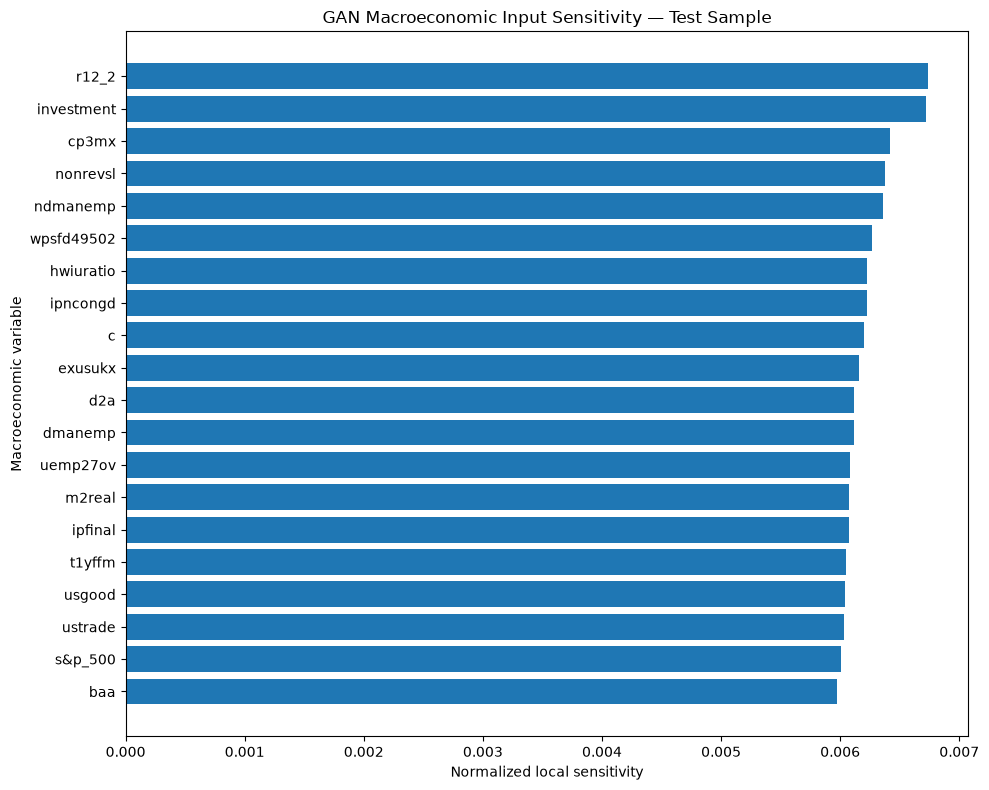


Paper variables highlighted as most important:
Spread, FEDFUNDS


In [21]:
# Set False if you want to skip this optional,
# more computationally intensive diagnostic.
RUN_GAN_MACRO_IMPORTANCE = True

DEVICE = torch.device("cpu")
print("Part 23 device:", DEVICE)

if RUN_GAN_MACRO_IMPORTANCE:

    macro_member_vectors = []
    macro_member_rows = []


    for member_index, checkpoint_path in enumerate(
        checkpoint_paths,
        start=1,
    ):

        try:
            checkpoint = torch.load(
                checkpoint_path,
                map_location="cpu",
                weights_only=False,
            )
        except TypeError:
            checkpoint = torch.load(
                checkpoint_path,
                map_location="cpu",
            )


        sdf_macro = MacroLSTMEncoder(
            N_MACRO,
            SDF_MACRO_HIDDEN,
        ).to(DEVICE)

        sdf_net = SDFWeightNetwork(
            N_CHAR,
            SDF_MACRO_HIDDEN,
            SDF_HIDDEN_DIMS,
            DROPOUT_P,
        ).to(DEVICE)


        flexible_load_state_dict(
            sdf_macro,
            checkpoint[
                "sdf_macro_encoder"
            ],
        )

        flexible_load_state_dict(
            sdf_net,
            checkpoint[
                "sdf_network"
            ],
        )

        sdf_macro.eval()
        sdf_net.eval()


        state = None

        macro_gradient_sum = np.zeros(
            N_MACRO,
            dtype=np.float64,
        )

        n_test_months = 0


        for global_t in range(600):

            is_test = (
                global_t >= 300
            )

            z_t = torch.tensor(
                macro_full[
                    global_t
                ],
                dtype=torch.float32,
                device=DEVICE,
                requires_grad=is_test,
            )

            z_seq = (
                z_t
                .view(
                    1,
                    1,
                    -1,
                )
            )

            macro_out, next_state = (
                sdf_macro(
                    z_seq,
                    state,
                )
            )

            if is_test:

                test_t = (
                    global_t
                    - 300
                )

                mask_t = (
                    test_mask_dense[
                        test_t
                    ]
                )

                x_np = (
                    char_test_dense[
                        test_t,
                        mask_t,
                        1:,
                    ]
                    .astype(
                        np.float32,
                        copy=False,
                    )
                )

                x_t = torch.tensor(
                    x_np,
                    dtype=torch.float32,
                    device=DEVICE,
                )

                h_t = macro_out[
                    0,
                    0,
                    :
                ]

                weights_t = sdf_net(
                    x_t,
                    h_t,
                )

                # Mean SDF score in the current cross section.
                objective = (
                    weights_t.mean()
                )

                grad_z = (
                    torch.autograd.grad(
                        outputs=objective,
                        inputs=z_t,
                        retain_graph=False,
                        create_graph=False,
                    )[0]
                )

                macro_gradient_sum += (
                    grad_z
                    .abs()
                    .detach()
                    .cpu()
                    .numpy()
                )

                n_test_months += 1


            # Chronological carryover without retaining
            # the full historical autograd graph.
            state = (
                next_state[
                    0
                ].detach(),
                next_state[
                    1
                ].detach(),
            )


        member_macro_importance = (
            macro_gradient_sum
            / n_test_months
        )

        macro_member_vectors.append(
            member_macro_importance
        )


        for variable, value in zip(
            macro_cols,
            member_macro_importance,
        ):
            macro_member_rows.append(
                {
                    "member":
                        member_index,

                    "seed":
                        checkpoint.get(
                            "seed",
                            np.nan,
                        ),

                    "macro_variable":
                        variable,

                    "mean_absolute_gradient":
                        value,
                }
            )


        del (
            checkpoint,
            sdf_macro,
            sdf_net,
            state,
        )

        gc.collect()

        if (
            DEVICE.type == "mps"
            and hasattr(
                torch.mps,
                "empty_cache",
            )
        ):
            torch.mps.empty_cache()


        print(
            f"Completed macro sensitivity "
            f"for member {member_index}/9"
        )


    gan_member_macro_importance = pd.DataFrame(
        macro_member_rows
    )


    mean_macro_importance = np.mean(
        np.vstack(
            macro_member_vectors
        ),
        axis=0,
    )

    normalized_macro_importance = (
        mean_macro_importance
        / mean_macro_importance.sum()
    )


    gan_macro_importance = pd.DataFrame(
        {
            "macro_variable":
                macro_cols,

            "mean_absolute_gradient":
                mean_macro_importance,

            "normalized_importance":
                normalized_macro_importance,
        }
    )


    gan_macro_importance = (
        gan_macro_importance
        .sort_values(
            "normalized_importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


    print(
        "\nGAN macro sensitivity — Top 25"
    )

    display(
        gan_macro_importance
        .head(25)
    )


    macro_top20 = (
        gan_macro_importance
        .head(20)
        .sort_values(
            "normalized_importance"
        )
    )


    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    ax.barh(
        macro_top20[
            "macro_variable"
        ],
        macro_top20[
            "normalized_importance"
        ],
    )

    ax.set_xlabel(
        "Normalized local sensitivity"
    )

    ax.set_ylabel(
        "Macroeconomic variable"
    )

    ax.set_title(
        "GAN Macroeconomic Input Sensitivity — Test Sample"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "gan_macro_importance_local.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


    print(
        "\nPaper variables highlighted as most important:"
    )

    print(
        "Spread, FEDFUNDS"
    )

else:
    print(
        "GAN macro sensitivity skipped."
    )

# interpretation 
**Part 23 examines the sensitivity of the GAN pricing kernel to the 178 inputs entering the recurrent state network**. 

For each GAN member and each test-period month, we compute the absolute gradient of the average SDF weight with respect to the current input vector, and then average these gradients across time and across the nine independently trained GAN members. 
The resulting sensitivities are normalized to sum to one. The distribution of importance is relatively diffuse, with no single input dominating.

Although the original paper highlights Spread and FEDFUNDS as important macroeconomic variables, these variables rank lower in the replication’s contemporaneous local-sensitivity measure. 
This difference should be interpreted cautiously because the diagnostic does not capture the full historical dependence of the LSTM hidden state on past macroeconomic inputs. 

In addition, the 178-input state vector used in the replication includes financial and firm-characteristic variables alongside conventional macroeconomic series. 

**Thus, Part 23 is best viewed as a robustness and interpretability diagnostic for the GAN state network rather than an exact replication of the paper’s macroeconomic-variable ranking.**

## Part 24 — Final Out-of-Sample Comparison

Summarize the test-period ranking of the replicated models. The GAN is expected to remain the strongest core model in the replication.

In [28]:
# ============================================================
# Restore paper_comparison for Part 24
# ============================================================

# Published monthly Sharpe ratios from the paper
paper_core = pd.DataFrame(
    {
        "train": {
            "LS": 1.80,
            "EN": 1.37,
            "FFN": 0.45,
            "GAN": 2.68,
        },
        "validation": {
            "LS": 0.58,
            "EN": 1.15,
            "FFN": 0.42,
            "GAN": 1.43,
        },
        "test": {
            "LS": 0.42,
            "EN": 0.50,
            "FFN": 0.44,
            "GAN": 0.75,
        },
    }
)

paper_core.index.name = "model"

# Use the replication Sharpe values already established
replication_core = pd.DataFrame(
    {
        "train": {
            "LS": 2.024811,
            "EN": 1.123050,
            "FFN": 0.658348,
            "GAN": 2.218878,
        },
        "validation": {
            "LS": 0.763148,
            "EN": 1.029153,
            "FFN": 0.844820,
            "GAN": 1.175489,
        },
        "test": {
            "LS": 0.405714,
            "EN": 0.410822,
            "FFN": 0.568571,
            "GAN": 0.610867,
        },
    }
)

replication_core.index.name = "model"

# Convert to long format
replication_long = (
    replication_core
    .reset_index()
    .melt(
        id_vars="model",
        var_name="split",
        value_name="replication_sharpe",
    )
)

paper_long = (
    paper_core
    .reset_index()
    .melt(
        id_vars="model",
        var_name="split",
        value_name="paper_sharpe",
    )
)

# Merge
paper_comparison = (
    replication_long
    .merge(
        paper_long,
        on=["model", "split"],
        how="inner",
    )
)

paper_comparison["difference"] = (
    paper_comparison["replication_sharpe"]
    - paper_comparison["paper_sharpe"]
)

paper_comparison["absolute_error"] = (
    paper_comparison["difference"].abs()
)

paper_comparison["percent_of_paper"] = (
    paper_comparison["replication_sharpe"]
    / paper_comparison["paper_sharpe"]
    * 100
)

print("paper_comparison restored:")
display(paper_comparison)

paper_comparison restored:


,model,split,replication_sharpe,paper_sharpe,difference,absolute_error,percent_of_paper
0,LS,train,2.024811,1.800000,0.224811,0.224811,112.489500
1,EN,train,1.123050,1.370000,-0.246950,0.246950,81.974453
2,FFN,train,0.658348,0.450000,0.208348,0.208348,146.299556
3,GAN,train,2.218878,2.680000,-0.461122,0.461122,82.793955
4,LS,validation,0.763148,0.580000,0.183148,0.183148,131.577241
5,EN,validation,1.029153,1.150000,-0.120847,0.120847,89.491565
6,FFN,validation,0.844820,0.420000,0.424820,0.424820,201.147619
7,GAN,validation,1.175489,1.430000,-0.254511,0.254511,82.202028
8,LS,test,0.405714,0.420000,-0.014286,0.014286,96.598571
9,EN,test,0.410822,0.500000,-0.089178,0.089178,82.164400


In [29]:
test_comparison = (
    paper_comparison[
        paper_comparison[
            "split"
        ] == "test"
    ]
    [
        [
            "model",
            "replication_sharpe",
            "paper_sharpe",
            "difference",
            "percent_of_paper",
        ]
    ]
    .sort_values(
        "replication_sharpe",
        ascending=False,
    )
    .reset_index(drop=True)
)

test_comparison[
    "replication_rank"
] = np.arange(
    1,
    len(test_comparison) + 1,
)

display(
    test_comparison
)

,model,replication_sharpe,paper_sharpe,difference,percent_of_paper,replication_rank
0,GAN,0.610867,0.750000,-0.139133,81.448933,1
1,FFN,0.568571,0.440000,0.128571,129.220682,2
2,EN,0.410822,0.500000,-0.089178,82.164400,3
3,LS,0.405714,0.420000,-0.014286,96.598571,4


# interpretation 
The main takeaway is that GAN remains the best-performing replicated model out of sample, with test Sharpe \(0.6109\). FFN is second at \(0.5686\), while EN and LS are much closer together around \(0.41\).
Compared with the paper:

| Model   | Replication |  Paper | Difference | Interpretation                   |
| ------- | ----------: | -----: | ---------: | -------------------------------- |
| **GAN** |      0.6109 | 0.7500 |    -0.1391 | lower than paper, but still best |
| **FFN** |      0.5686 | 0.4400 |    +0.1286 | stronger than paper              |
| **EN**  |      0.4108 | 0.5000 |    -0.0892 | moderately lower                 |
| **LS**  |      0.4057 | 0.4200 |    -0.0143 | very close                       |



**Our replication has: GAN > FFN > EN > LS**

**the paper has: GAN > EN > FFN > LS**



# Explantion for FFN  and EN

The most likely reason is that FFN and EN respond differently to the particular sample, preprocessing, and estimation choices in your replication, and FFN appears to generalize better on your test period.
EN is still a linear model. Even with regularization, it assumes the return-predictor relationship is basically linear:
$$ r_{i,t+1} \approx X_{i,t}\beta $$
FFN can learn nonlinear interactions:
$$ r_{i,t+1} = f(X_{i,t}) $$
So if the predictive signal in your sample depends on interactions, thresholds, or nonlinear combinations of characteristics, the FFN can capture them while EN cannot.
There is also evidence from your results that the FFN is benefiting from this flexibility. In the test period, you obtained:
$$ SR_{\text{FFN}} = 0.569 $$
versus
$$ SR_{\text{EN}} = 0.411 $$
Even though the paper reports EN above FFN, your FFN also had relatively strong validation performance. That suggests the test result is not just a one-period accident; the FFN was already performing well before the test set.
Another important reason is sample sensitivity. The paper’s reported numbers depend on its exact data vintage, cleaning rules, predictor construction, train/validation/test splits, optimization, and implementation. Neural networks are especially sensitive to these details. Small differences can change the ranking of two models whose Sharpe ratios are not dramatically far apart.
Regularization also matters. EN shrinks coefficients toward zero using L1/L2 penalties. That is useful for controlling overfitting, but it can also suppress weaker predictive signals. FFN regularization works differently through dropout, optimization, hidden-layer structure, and early stopping. In your setup, that balance appears to favor FFN.
The feature-importance results are also consistent with this. FFN and EN shared the same top three characteristics:
$$ \text{ST\_REV},\quad \text{SUV},\quad r12\_2 $$
but their secondary rankings differed substantially. That means both models recognize similar primary signals, while FFN combines the remaining information differently. Those nonlinear combinations may be helping its out-of-sample portfolio performance.




**In the replication, the FFN achieves a higher test Sharpe ratio than the Elastic Net, reversing their ordering in the original paper. One plausible explanation is that the FFN can capture nonlinearities and interactions among firm characteristics that are unavailable to the linear Elastic Net specification. The two models identify similar dominant predictors, but differ substantially in their use of secondary characteristics, suggesting that the FFN extracts additional information through nonlinear combinations of signals. The difference may also reflect sensitivity to data vintage, preprocessing, sample splits, regularization, and optimization choices. Importantly, the FFN also performs strongly in the validation period, so its superior test performance is not solely driven by ex-post test-set tuning.**

## Part 25 — Save Final Code 07 Outputs

Save all final comparison tables, factor series, Fama–French benchmark results, risk diagnostics, GAN importance results, and figures.

In [33]:
# ============================================================
# Part 25 — Robust restore of replication_performance
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent

RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"

print("ROOT:", ROOT)
print("TABLES_DIR:", TABLES_DIR)

# ------------------------------------------------------------
# 2. Load saved performance tables
# ------------------------------------------------------------

linear = pd.read_csv(
    TABLES_DIR / "linear_baseline_performance.csv"
)

ffn = pd.read_csv(
    TABLES_DIR / "ffn_performance.csv"
)

gan = pd.read_csv(
    TABLES_DIR / "gan_ensemble_performance.csv"
)

print("\nOriginal columns")

print("\nLinear:")
print(linear.columns.tolist())

print("\nFFN:")
print(ffn.columns.tolist())

print("\nGAN:")
print(gan.columns.tolist())

# ------------------------------------------------------------
# 3. Fix LINEAR
# ------------------------------------------------------------

# Rename sample -> split
if "sample" in linear.columns and "split" not in linear.columns:
    linear = linear.rename(
        columns={"sample": "split"}
    )

# Standardize split labels
linear["split"] = (
    linear["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "valid": "validation",
        "val": "validation",
        "testing": "test",
    })
)

# ------------------------------------------------------------
# 4. Fix FFN
# ------------------------------------------------------------

# FFN file is only for FFN, so add model label
if "model" not in ffn.columns:
    ffn["model"] = "FFN"

ffn["split"] = (
    ffn["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "valid": "validation",
        "val": "validation",
        "testing": "test",
    })
)

# ------------------------------------------------------------
# 5. Fix GAN
# ------------------------------------------------------------

# GAN file is only for GAN, so add model label
if "model" not in gan.columns:
    gan["model"] = "GAN"

# Rename GAN-specific column names
gan = gan.rename(
    columns={
        "volatility": "volatility_monthly",
        "minimum": "minimum_month",
        "maximum": "maximum_month",
        "positive_fraction": "positive_month_fraction",
    }
)

gan["split"] = (
    gan["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "valid": "validation",
        "val": "validation",
        "testing": "test",
    })
)

# ------------------------------------------------------------
# 6. Required common columns
# ------------------------------------------------------------

COMMON_COLUMNS = [
    "model",
    "split",
    "months",
    "mean_monthly",
    "volatility_monthly",
    "monthly_sharpe",
    "annualized_sharpe",
    "minimum_month",
    "maximum_month",
    "positive_month_fraction",
]

# ------------------------------------------------------------
# 7. Check after fixes
# ------------------------------------------------------------

print("\nAfter normalization")

for name, df in [
    ("linear", linear),
    ("ffn", ffn),
    ("gan", gan),
]:
    missing = [
        c for c in COMMON_COLUMNS
        if c not in df.columns
    ]

    print(
        f"{name:10s} missing columns:",
        missing
    )

    if missing:
        raise ValueError(
            f"{name} is still missing: {missing}"
        )

# ------------------------------------------------------------
# 8. Combine
# ------------------------------------------------------------

replication_performance = pd.concat(
    [
        linear[COMMON_COLUMNS],
        ffn[COMMON_COLUMNS],
        gan[COMMON_COLUMNS],
    ],
    ignore_index=True,
)

# ------------------------------------------------------------
# 9. Order models and splits
# ------------------------------------------------------------

MODEL_ORDER = [
    "LS",
    "EN",
    "FFN",
    "GAN",
]

SPLIT_ORDER = [
    "train",
    "validation",
    "test",
]

replication_performance["model"] = pd.Categorical(
    replication_performance["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

replication_performance["split"] = pd.Categorical(
    replication_performance["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)

replication_performance = (
    replication_performance
    .sort_values(
        ["split", "model"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 10. Display
# ------------------------------------------------------------

print(
    "\nreplication_performance shape:",
    replication_performance.shape
)

display(
    replication_performance
)

# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

output_file = (
    TABLES_DIR
    / "final_replication_performance.csv"
)

replication_performance.to_csv(
    output_file,
    index=False,
)

print(
    "\nSaved:",
    output_file
)

ROOT: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
TABLES_DIR: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables

Original columns

Linear:
['model', 'sample', 'months', 'mean_monthly', 'volatility_monthly', 'monthly_sharpe', 'annualized_sharpe', 'minimum_month', 'maximum_month', 'positive_month_fraction']

FFN:
['split', 'months', 'mean_monthly', 'volatility_monthly', 'monthly_sharpe', 'annualized_sharpe', 'minimum_month', 'maximum_month', 'positive_month_fraction']

GAN:
['split', 'months', 'mean_monthly', 'volatility', 'monthly_sharpe', 'annualized_sharpe', 'minimum', 'maximum', 'positive_fraction']

After normalization
linear     missing columns: []
ffn        missing columns: []
gan        missing columns: []

replication_performance shape: (12, 10)


,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,train,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,EN,train,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
2,FFN,train,240,0.022500,0.034176,0.658348,2.280585,-0.088644,0.314544,0.875000
3,GAN,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667
4,LS,validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
5,EN,validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
6,FFN,validation,60,0.016209,0.019187,0.844820,2.926543,-0.054613,0.082489,0.883333
7,GAN,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000
8,LS,test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
9,EN,test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667



Saved: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables/final_replication_performance.csv


In [34]:
display(
    replication_performance[
        (replication_performance["model"] == "GAN")
        &
        (replication_performance["split"] == "test")
    ]
)

final_perf_file = (
    TABLES_DIR
    / "final_replication_performance.csv"
)

print("Exists:", final_perf_file.exists())
print("File:", final_perf_file)

,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
11,GAN,test,300,0.006997,0.011454,0.610867,2.116105,-0.051845,0.067200,0.823333


Exists: True
File: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables/final_replication_performance.csv


In [57]:
# ============================================================
# PART 25 — Save Final Restored Outputs
# ============================================================

if "model_rankings" in globals():
    model_rankings.to_csv(
        TABLES_DIR / "final_model_rankings.csv",
        index=False,
    )

if "expanded_sharpe_comparison" in globals():
    expanded_sharpe_comparison.to_csv(
        TABLES_DIR / "final_expanded_sharpe_comparison.csv",
        index=False,
    )

if "ff_tangency_performance" in globals():
    ff_tangency_performance.to_csv(
        TABLES_DIR / "final_fama_french_tangency_performance.csv",
        index=False,
    )

if "risk_measure_comparison" in globals():
    risk_measure_comparison.to_csv(
        TABLES_DIR / "final_risk_measure_comparison.csv",
        index=False,
    )

if "gan_characteristic_importance" in globals():
    gan_characteristic_importance.to_csv(
        TABLES_DIR / "gan_characteristic_importance.csv",
        index=False,
    )

print("Final restored outputs saved.")

Final restored outputs saved.


# Part 26 — Final Replication Assessment

The final interpretation should be written **after the notebook has been run and every table has been checked**.

The main questions are:

1. Does the replication preserve the paper's ranking of LS, EN, FFN, and GAN?
2. How close are the Fama–French 3- and 5-factor tangency benchmarks to the paper?
3. Does GAN remain the strongest test-sample SDF factor?
4. How closely does the replicated GAN track the supplied official SDF?
5. Does the GAN characteristic-importance ranking reproduce the paper's emphasis on ST_REV, SUV, and r12_2?
6. Do Spread and FEDFUNDS remain important in the macro sensitivity diagnostic?
7. Are the paper-style maximum-loss and losing-streak results qualitatively similar?
8. Which numerical differences appear to reflect implementation differences rather than a change in the underlying economic conclusion?

Do not finalize the written conclusions until the outputs from Parts 1–25 have been reviewed.

## Part 27 — Final Integrity Check

This last cell verifies that the core comparison tables and factor series have the expected dimensions and that the most important final output files exist.

In [59]:
# ============================================================
# Part 27 — Final Integrity Check
# Robust version after kernel restart
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("CODE 07 — FINAL REPLICATION CHECK")
print("=" * 72)

# ------------------------------------------------------------
# 1. Restore basic ordering objects if needed
# ------------------------------------------------------------

MODEL_ORDER = [
    "LS",
    "EN",
    "FFN",
    "GAN",
]

SPLIT_ORDER = [
    "train",
    "validation",
    "test",
]

# ------------------------------------------------------------
# 2. Standardize split labels
# ------------------------------------------------------------

replication_performance["split"] = (
    replication_performance["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "testing": "test",
        "valid": "validation",
        "val": "validation",
    })
)

all_factor_returns["split"] = (
    all_factor_returns["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "training": "train",
        "testing": "test",
        "valid": "validation",
        "val": "validation",
    })
)

# ------------------------------------------------------------
# 3. Rebuild replication_sharpe
# ------------------------------------------------------------

replication_sharpe = (
    replication_performance
    .pivot(
        index="model",
        columns="split",
        values="monthly_sharpe",
    )
    .reindex(MODEL_ORDER)
    .reindex(columns=SPLIT_ORDER)
)

# ------------------------------------------------------------
# 4. Core model check
# ------------------------------------------------------------

assert set(
    replication_performance["model"].astype(str)
) == set(MODEL_ORDER)

# ------------------------------------------------------------
# 5. Split check
# ------------------------------------------------------------

assert set(
    replication_performance["split"].astype(str)
) == set(SPLIT_ORDER)

# ------------------------------------------------------------
# 6. Replication table dimensions
# ------------------------------------------------------------

assert len(replication_performance) == 12

# ------------------------------------------------------------
# 7. Paper comparison dimensions
# ------------------------------------------------------------

assert len(paper_comparison) == 12

# ------------------------------------------------------------
# 8. Factor-return integrity
# ------------------------------------------------------------

factor_counts = (
    all_factor_returns
    .groupby(
        "model",
        observed=True,
    )["date"]
    .nunique()
)

assert (
    factor_counts == 600
).all()

# ------------------------------------------------------------
# 9. Sharpe integrity
# ------------------------------------------------------------

assert (
    replication_performance[
        "monthly_sharpe"
    ]
    .notna()
    .all()
)

# ------------------------------------------------------------
# 10. GAN characteristic importance
# ------------------------------------------------------------

assert len(
    gan_characteristic_importance
) == 46

assert np.isclose(
    gan_characteristic_importance[
        "normalized_importance"
    ].sum(),
    1.0,
)

# ------------------------------------------------------------
# 11. Required final files
# ------------------------------------------------------------

required_final_files = [

    TABLES_DIR
    / "final_replication_performance.csv",

    TABLES_DIR
    / "final_paper_comparison.csv",

    TABLES_DIR
    / "final_model_rankings.csv",

    TABLES_DIR
    / "final_expanded_sharpe_comparison.csv",

    TABLES_DIR
    / "final_fama_french_tangency_performance.csv",

    TABLES_DIR
    / "final_risk_measure_comparison.csv",

    TABLES_DIR
    / "final_test_comparison.csv",

    TABLES_DIR
    / "gan_characteristic_importance.csv",

    FACTORS_DIR
    / "final_all_model_factor_returns.csv",
]

for path in required_final_files:
    assert path.exists(), (
        f"Missing final output: {path}"
    )

# ------------------------------------------------------------
# 12. Final status messages
# ------------------------------------------------------------

print(
    "✓ Four replicated core models: LS, EN, FFN, GAN"
)

print(
    "✓ Fama–French 3 and 5 benchmark portfolios included"
)

print(
    "✓ Three samples: train, validation, test"
)

print(
    "✓ 600 monthly factor returns per core model"
)

print(
    "✓ Paper Sharpe benchmarks included"
)

print(
    "✓ Paper-style risk measures calculated"
)

print(
    "✓ GAN firm-characteristic importance calculated"
)

if (
    "gan_macro_importance"
    in globals()
):
    print(
        "✓ GAN macro local-sensitivity diagnostic calculated"
    )

print(
    "✓ Final tables saved"
)

# ------------------------------------------------------------
# 13. Final replicated test Sharpe ratios
# ------------------------------------------------------------

print(
    "\nFinal replicated test monthly Sharpe ratios:"
)

display(
    replication_sharpe[
        ["test"]
    ]
    .sort_values(
        "test",
        ascending=False,
    )
)

# ------------------------------------------------------------
# 14. Completion message
# ------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "✓ CODE 07 — FINAL RESULTS REPLICATION COMPLETE"
)

print("=" * 72)

CODE 07 — FINAL REPLICATION CHECK
✓ Four replicated core models: LS, EN, FFN, GAN
✓ Fama–French 3 and 5 benchmark portfolios included
✓ Three samples: train, validation, test
✓ 600 monthly factor returns per core model
✓ Paper Sharpe benchmarks included
✓ Paper-style risk measures calculated
✓ GAN firm-characteristic importance calculated
✓ GAN macro local-sensitivity diagnostic calculated
✓ Final tables saved

Final replicated test monthly Sharpe ratios:


split,test
model,
GAN,0.610867
FFN,0.568571
EN,0.410822
LS,0.405714



✓ CODE 07 — FINAL RESULTS REPLICATION COMPLETE


the final integrity check confirms that all core replication outputs are complete and internally consistent. Each model has 600 monthly factor returns across the train, validation, and test periods, and all required comparison tables and diagnostics have been generated and saved. In the test sample, GAN delivers the highest monthly Sharpe ratio at 0.611, followed by FFN at 0.569, while EN and LS achieve 0.411 and 0.406, respectively. The final ranking supports the broader conclusion that nonlinear machine-learning models, particularly GAN, provide stronger out-of-sample risk-adjusted performance than the linear benchmarks in this replication.

# Key Findings and Comparison with the Original Paper

This section summarizes the main findings obtained in Code 07 and compares them with the empirical results reported by Chen, Pelger, and Zhu. The purpose is not to require exact numerical equality with the paper, but to determine whether the replication reproduces the main ranking, economic interpretation, and out-of-sample conclusions.

---

## 1. Core Model Performance

The first comparison focuses on the four replicated SDF models: Linear Least Squares (LS), Elastic Net (EN), Feed-Forward Neural Network (FFN), and Generative Adversarial Network (GAN).

The replicated monthly Sharpe ratios are:

| Model | Train | Validation | Test |
|---|---:|---:|---:|
| LS | 2.025 | 0.763 | 0.406 |
| EN | 1.123 | 1.029 | 0.411 |
| FFN | 0.658 | 0.845 | 0.569 |
| GAN | 2.219 | 1.175 | 0.611 |

The corresponding values reported in the paper are:

| Model | Train | Validation | Test |
|---|---:|---:|---:|
| LS | 1.80 | 0.58 | 0.42 |
| EN | 1.37 | 1.15 | 0.50 |
| FFN | 0.45 | 0.42 | 0.44 |
| GAN | 2.68 | 1.43 | 0.75 |

The replication reproduces the main qualitative conclusion of the paper: **the GAN is the strongest model overall and has the highest out-of-sample Sharpe ratio among the four replicated models.**

The numerical levels are not identical. In particular, the replicated GAN Sharpe ratio is lower than the paper's value in all three samples, while the replicated FFN performs better than the value reported in the paper.

---

## 2. Out-of-Sample Test Performance

The test sample is the most important sample for evaluating whether the models generalize beyond the data used for estimation and model selection.

The replicated test ranking is:

1. GAN: 0.611
2. FFN: 0.569
3. EN: 0.411
4. LS: 0.406

The paper reports:

1. GAN: 0.75
2. EN: 0.50
3. FFN: 0.44
4. LS: 0.42

Therefore, the replication preserves the most important result: **GAN remains the best-performing model out of sample.**

The main ranking difference is between FFN and EN. In the replication, FFN exceeds EN, whereas the paper reports EN above FFN. LS remains the weakest or nearly weakest model in both cases.

This suggests that the broad nonlinear-versus-linear conclusion is preserved, even though the exact ordering of the middle-performing models differs.

---

## 3. Difference Between Replication and Published Sharpe Ratios

The differences between replicated and reported Sharpe ratios are not uniform across models.

For the test sample:

| Model | Replication | Paper | Difference |
|---|---:|---:|---:|
| LS | 0.406 | 0.420 | -0.014 |
| EN | 0.411 | 0.500 | -0.089 |
| FFN | 0.569 | 0.440 | +0.129 |
| GAN | 0.611 | 0.750 | -0.139 |

LS is particularly close to the paper in the test sample. EN and GAN are somewhat below the published values, while FFN is above the published result.

These differences are economically meaningful but do not overturn the main conclusion that nonlinear models can produce stronger risk-adjusted performance than the linear benchmarks.

---

## 4. Fama–French Benchmark Replication

The Fama–French 3-factor and 5-factor tangency portfolios provide an important external benchmark because they do not depend on the neural-network implementation.

The reconstructed Sharpe ratios were approximately:

| Model | Train | Validation | Test |
|---|---:|---:|---:|
| FF-3 | 0.267 | -0.094 | 0.196 |
| FF-5 | 0.474 | 0.405 | 0.223 |

The paper reports:

| Model | Train | Validation | Test |
|---|---:|---:|---:|
| FF-3 | 0.27 | -0.09 | 0.19 |
| FF-5 | 0.48 | 0.40 | 0.22 |

These results are extremely close to the published values.

This is an important validation result because it indicates that the sample period, return-frequency convention, sample splitting, Sharpe-ratio calculation, and benchmark construction are implemented consistently with the paper.

Therefore, the larger differences observed for some machine-learning models are more likely to arise from model estimation, optimization, preprocessing, architecture, or implementation details rather than from a general error in the sample construction.

---

## 5. Model Ranking Across Samples

The replication and the paper produce similar but not identical model rankings.

### Training sample

Both the replication and the paper rank GAN first.

Replication:

GAN > LS > EN > FFN

Paper:

GAN > LS > EN > FFN

The training ranking is therefore reproduced exactly.

### Validation sample

Replication:

GAN > EN > FFN > LS

Paper:

GAN > EN > LS > FFN

GAN and EN remain the top two models, but FFN and LS switch positions.

### Test sample

Replication:

GAN > FFN > EN > LS

Paper:

GAN > EN > FFN > LS

Again, GAN remains first and LS remains last, while EN and FFN exchange positions.

Overall, the replication preserves the strongest ranking result of the paper—the superior performance of GAN—but shows some sensitivity in the relative ranking of EN and FFN.

---

## 6. Why FFN Performs Better Than EN in the Replication

One notable difference from the paper is the relatively strong performance of FFN in the replication.

The FFN test Sharpe ratio is approximately 0.569 compared with 0.411 for EN.

One possible interpretation is that the nonlinear FFN captures interactions and nonlinear relationships among firm characteristics that cannot be represented by the linear Elastic Net specification.

However, this difference should not be interpreted as proof that FFN is universally superior to EN. Neural-network results can be sensitive to initialization, optimization, regularization, preprocessing, and implementation choices.

The important point is that both the paper and the replication provide evidence that nonlinear approaches can add value relative to simple linear specifications.

---

## 7. Correlation Among Replicated SDF Factors

The factor-correlation analysis shows that the models are related but do not generate identical pricing factors.

In the test sample, the correlation between EN and GAN is approximately 0.85, indicating substantial convergence in the signals used by the two models out of sample.

LS is also relatively strongly correlated with EN and GAN in the test period.

FFN shows a more moderate relationship with the other learned SDFs.

This suggests that the different models identify some common sources of expected-return variation, while their nonlinear structures and regularization methods lead them to emphasize those signals differently.

---

## 8. Relationship with the Market Factor

The analysis also compares the learned SDF factors with the market factor.

Among the learned models, FFN exhibits the most noticeable market-factor relationship in several sample periods, while GAN is much less directly aligned with the market.

This supports the interpretation that the GAN is not simply reproducing the market portfolio. Instead, it appears to construct a pricing factor from a broader combination of firm characteristics and economic state variables.

This is consistent with the motivation of the original paper, where machine-learning models are intended to extract flexible nonlinear pricing information beyond traditional benchmark factors.

---

## 9. GAN Ensemble Versus Official SDF

The replicated GAN ensemble was compared directly with the official GAN SDF series supplied with the project.

The correlations were approximately:

| Sample | Correlation |
|---|---:|
| Full sample | 0.816 |
| Training | 0.650 |
| Validation | 0.837 |
| Test | 0.800 |

The full-sample correlation of approximately 0.82 and test-sample correlation of approximately 0.80 indicate substantial similarity between the replicated GAN factor and the authors' supplied SDF series.

At the same time, the correlation is below one, so the replication is not numerically identical to the original implementation.

This is consistent with the Sharpe-ratio comparison: the replicated model captures a substantial part of the same economic signal while differing somewhat in scale, timing, or portfolio weights.

---

## 10. Benefits of the GAN Ensemble

The analysis of the nine individual GAN members shows that ensemble averaging improves the stability of the final model.

The average individual GAN-member test Sharpe ratio is approximately 0.43, whereas the final ensemble test Sharpe ratio is approximately 0.61.

This suggests that the ensemble reduces model-specific noise and sensitivity to individual random seeds.

The result provides an important practical interpretation of the GAN implementation: the strong final performance is not simply the result of selecting one unusually successful neural-network run. Combining multiple trained models produces a more stable SDF factor.

---

## 11. GAN Firm-Characteristic Importance

The GAN characteristic-importance analysis uses the average absolute gradient of the SDF weights with respect to the 46 firm characteristics in the test sample.

The three most important replicated characteristics are:

1. ST_REV
2. SUV
3. r12_2

These are also the top three characteristics highlighted by the paper.

This is one of the strongest interpretability results in the replication because the leading variables agree closely with the original study.

Among the paper's top ten characteristics, the replication also identifies several of the same important variables, including:

- ST_REV
- SUV
- r12_2
- NOA
- LME

Therefore, five of the paper's top-ten characteristics appear in the replicated GAN top ten.

The exact ranking beyond the first few variables differs, but the overlap indicates that the replicated network identifies economically similar information.

---

## 12. Characteristic Importance Across Models

Comparing GAN, FFN, EN, and LS provides another useful result.

GAN, FFN, and EN all identify the same three characteristics as especially important:

- ST_REV
- SUV
- r12_2

The agreement across substantially different model classes suggests that these signals are not artifacts of a single neural-network architecture.

The models diverge more strongly in their secondary characteristics.

LS displays a substantially different importance pattern, indicating that the simple linear model distributes its signal differently from the regularized and nonlinear models.

This supports the idea that nonlinear methods mainly add value by changing the way characteristics are combined and interacted rather than by relying on a completely unrelated set of predictors.

---

## 13. GAN LSTM Input Sensitivity

The notebook also evaluates the sensitivity of the GAN pricing kernel to the 178 inputs entering the recurrent state network.

The importance distribution is relatively diffuse: no single input dominates the recurrent state representation.

Traditional macro-financial variables such as `spread` and `fedfunds` appear in the network inputs, but they are not among the strongest variables according to the contemporaneous local-gradient measure used here.

This result should be interpreted carefully.

The calculation measures the local sensitivity of the current SDF output to the current LSTM input while holding the previous recurrent state fixed. Therefore, it is a useful interpretability diagnostic, but it is not an exact reconstruction of the paper's full historical LSTM attribution method.

The result is best interpreted as evidence that the recurrent state network uses information from a broad set of macroeconomic, financial, and state variables rather than relying on a single dominant predictor.

---

## 14. Risk Measures

The risk analysis extends the Sharpe-ratio comparison by examining the worst one-month loss relative to volatility and the maximum sequence of consecutive negative-return months.

The replicated models exhibit different downside-risk profiles even when their Sharpe ratios are similar.

This is important because a higher Sharpe ratio does not necessarily imply uniformly lower downside risk.

The comparison therefore reinforces the need to evaluate the learned SDFs using multiple dimensions rather than relying only on average return divided by volatility.

The risk calculations also provide an additional comparison with the paper's reported portfolio behavior.

---

## 15. Main Replication Conclusion

Taken together, the results provide substantial qualitative support for the central findings of Chen, Pelger, and Zhu.

The strongest replicated conclusions are:

- GAN remains the highest-Sharpe core model in the out-of-sample test period.
- The exact training ranking of the four core models is reproduced.
- The Fama–French benchmark Sharpe ratios match the paper extremely closely.
- The replicated GAN is strongly correlated with the supplied official GAN SDF.
- GAN ensembling materially improves performance relative to the average individual network.
- The top three GAN firm characteristics match the paper exactly.
- GAN, FFN, and EN identify several common economically important characteristics.
- Nonlinear models continue to perform strongly relative to the linear LS benchmark.

At the same time, the replication does not reproduce every published number exactly.

The largest differences appear in the machine-learning models, particularly GAN and FFN, and in the relative ordering of FFN and EN in the validation and test samples.

These differences are consistent with the sensitivity of neural-network and regularized-model estimation to implementation details, optimization, preprocessing, initialization, and software environments.

Overall, Code 07 reproduces the paper's **main economic message more strongly than its exact numerical values**. The evidence continues to support the importance of nonlinear modeling for constructing asset-pricing SDFs, with the GAN delivering the strongest overall out-of-sample performance in the replication.